In [1]:
import numpy as np
import pandas as pd
import scanpy as sc 

adata = sc.read_h5ad("dataset_co_mo.h5ad")

In [2]:
# Data prep
sc.pp.normalize_total(adata, target_sum=1e4) # You can adjust target_sum # Seems not to help
sc.pp.log1p(adata)

In [3]:
# Extract source and receiver genes efficiently
gl_source = ['TGFBR2', 'SMAD3', 'HIF1A', 'PDGFB'] # All values from the first column
gl_recv =['PDGFRB', 'FN1', 'TGFB1']  # All values from the second column

#gl_source = ['TGFBR2', 'HIF1A', 'PDGFB'] # All values from the first column
#gl_recv =['PDGFRB', 'FN1', 'TGFB1']  # All values from the second column

#gl_source = ['TGFBR2', 'PDGFB'] # All values from the first column
#gl_recv =['PDGFRB', 'TGFB1']  # All values from the second column

np.random.seed(42) 
pi_mul = np.pi

In [4]:
ict1 = adata.obs["BatchID"] == "Cancer Cells (Co)"
ict2 = adata.obs["BatchID"] == "Fibroblasts (Co)" 

adata_ct1_co = adata[ict1, gl_source]
adata_ct2_co = adata[ict2, gl_recv]
#adata_ct1_co = sc.external.pp.magic(adata_ct1_co, name_list=gl_source, knn=5, random_state=42)
#adata_ct2_co = sc.external.pp.magic(adata_ct2_co, name_list=gl_recv, knn=5, random_state=42)

print(adata_ct1_co)
print(adata_ct2_co)

Xct1_co = adata_ct1_co.X.toarray()
Xct2_co = adata_ct2_co.X.toarray()
#Xct1_co = adata_ct1_co.X
#Xct2_co = adata_ct2_co.X

# Assuming Xct1_co and Xct2 are your log-transformed expression matrices
Xct1means = np.mean(Xct1_co, axis=0) *0
Xct2means = np.mean(Xct2_co, axis=0) *0
print("CT1 (Co) mean expression:", Xct1means)
print("CT2 (Co) mean expression:", Xct2means)

# Binarize Xct1
Xct1_binary_co = (Xct1_co > Xct1means).astype(int)
# Binarize Xct2
Xct2_binary_co = (Xct2_co > Xct2means).astype(int)

# Calculate the proportion of cells with expression above mean for each gene in ct1
Xct1p_co = np.sum(Xct1_binary_co, axis=0) / len(Xct1_binary_co[:, 0])
# Calculate the proportion of cells with expression above mean for each gene in ct2
Xct2p_co = np.sum(Xct2_binary_co, axis=0) / len(Xct2_binary_co[:, 0])

print("CT1 (Co) Percentages:", Xct1p_co)
print("CT2 (Co) Percentages:", Xct2p_co)

# Scale the data from 0 to 1 to -pi/2 to pi/2 | 2*pi or pi?
#ct1_percentages_co = (Xct1p_co -0.5) * pi_mul + np.pi
#ct2_percentages_co = (Xct2p_co -0.5) * pi_mul + np.pi
ct1_percentages_co = Xct1p_co * pi_mul 
ct2_percentages_co = Xct2p_co * pi_mul 

# Display the resulting scaled data
print("Scaled (Co) ct1_data:\n", ct1_percentages_co)
print("Scaled (Co) ct2_data:\n", ct2_percentages_co)

View of AnnData object with n_obs × n_vars = 1414 × 4
    obs: 'CellID', 'BatchID', 'ClusterID', 'CellType', 'CellCycle'
    uns: 'log1p'
View of AnnData object with n_obs × n_vars = 1324 × 3
    obs: 'CellID', 'BatchID', 'ClusterID', 'CellType', 'CellCycle'
    uns: 'log1p'
CT1 (Co) mean expression: [0. 0. 0. 0.]
CT2 (Co) mean expression: [0. 0. 0.]
CT1 (Co) Percentages: [0.3748232  0.79915134 0.88260255 0.29915134]
CT2 (Co) Percentages: [0.41993958 0.99018127 0.51812689]
Scaled (Co) ct1_data:
 [1.1775418  2.51060799 2.77277767 0.93981166]
Scaled (Co) ct2_data:
 [1.31927909 3.1107462  1.62774363]


In [5]:
ict1 = adata.obs["BatchID"] == "Cancer Cells (Mo)"
ict2 = adata.obs["BatchID"] == "Fibroblasts (Mo)" 

adata_ct1_mo = adata[ict1, gl_source]
adata_ct2_mo = adata[ict2, gl_recv]
#adata_ct1_mo = sc.external.pp.magic(adata_ct1_mo, name_list=gl_source, knn=5, random_state=42)
#adata_ct2_mo = sc.external.pp.magic(adata_ct2_mo, name_list=gl_recv, knn=5, random_state=42)

print(adata_ct1_mo)
print(adata_ct2_mo)

# Library size normalization 
Xct1_mo = adata_ct1_mo.X.toarray()
Xct2_mo = adata_ct2_mo.X.toarray()
#Xct1_mo = adata_ct1_mo.X
#Xct2_mo = adata_ct2_mo.X


# Assuming Xct1_co and Xct2 are your log-transformed expression matrices
#Xct1means = np.mean(Xct1_mo, axis=0)
#Xct2means = np.mean(Xct2_mo, axis=0)
#print("CT1 (Co) mean expression:", Xct1means)
#print("CT2 (Co) mean expression:", Xct2means)

# Utilize the mono cultured means here
# Binarize Xct1
Xct1_binary_mo = (Xct1_mo > Xct1means).astype(int)
# Binarize Xct2
Xct2_binary_mo = (Xct2_mo > Xct2means).astype(int)

# Calculate the proportion of cells with expression above mean for each gene in ct1
Xct1p_mo = np.sum(Xct1_binary_mo, axis=0) / len(Xct1_binary_mo[:, 0])

# Calculate the proportion of cells with expression above mean for each gene in ct2
Xct2p_mo = np.sum(Xct2_binary_mo, axis=0) / len(Xct2_binary_mo[:, 0])

print("CT1 (Mo) Percentages:", Xct1p_mo)
print("CT2 (Mo) Percentages:", Xct2p_mo)

# Scale the data from 0 to 1 to -pi/2 to pi/2 | 2*pi or pi?
#ct1_percentages_mo = (Xct1p_mo -0.5) * pi_mul + np.pi/2
#ct2_percentages_mo = (Xct2p_mo -0.5) * pi_mul + np.pi/2
ct1_percentages_mo = Xct1p_mo * pi_mul 
ct2_percentages_mo = Xct2p_mo * pi_mul

# Display the resulting scaled data
print("Scaled (Mo) ct1_data:\n", ct1_percentages_mo)
print("Scaled (Mo) ct2_data:\n", ct2_percentages_mo)

View of AnnData object with n_obs × n_vars = 2364 × 4
    obs: 'CellID', 'BatchID', 'ClusterID', 'CellType', 'CellCycle'
    uns: 'log1p'
View of AnnData object with n_obs × n_vars = 2788 × 3
    obs: 'CellID', 'BatchID', 'ClusterID', 'CellType', 'CellCycle'
    uns: 'log1p'
CT1 (Mo) Percentages: [0.36759729 0.8071066  0.89932318 0.09898477]
CT2 (Mo) Percentages: [0.29196557 0.98134864 0.42969871]
Scaled (Mo) ct1_data:
 [1.15484095 2.53560016 2.8253071  0.31096983]
Scaled (Mo) ct2_data:
 [0.91723688 3.08299767 1.34993831]


In [6]:
print(adata_ct1_co.var_names)
print(adata_ct2_co.var_names)

Index(['TGFBR2', 'SMAD3', 'HIF1A', 'PDGFB'], dtype='object')
Index(['PDGFRB', 'FN1', 'TGFB1'], dtype='object')


In [7]:
import sys
import os

# Replace with your actual path
cc_grn_functions_path = r"C:\Users\ssromerogon\Documents\vscode_working_dir\QuantumXCT\python\cc_grn_functions"
#cc_grn_functions_path = r"C:\Users\selim\Documents\vs_working_dir\QuantumXCT\python\cc_grn_functions"
sys.path.append(cc_grn_functions_path)

from histogram_functions import create_joint_histogram, plot_joint_histogram, create_percent_joint_histogram, count_boolean_vector_occurrences

In [9]:
import sys
import os

# Replace with your actual path
cc_grn_functions_path = r"C:\Users\ssromerogon\Documents\vscode_working_dir\QuantumXCT\python\cc_grn_functions"
#cc_grn_functions_path = r"C:\Users\selim\Documents\vs_working_dir\QuantumXCT\python\cc_grn_functions"
sys.path.append(cc_grn_functions_path)

from quantum_functions import create_grn_ansatz, create_interaction_observable_from_histogram, evaluate_and_plot_ansatz
from quantum_functions import create_parameter_dictionaries, cost_func_vqe, cost_func_wrapper
from quantum_functions import create_interaction_observable_general, create_parameter_dictionaries_from_circuit, create_joint_circuit_from_ansatzes, vqe_solver
from quantum_functions import prob_dist_matching_solver
import matplotlib.pyplot as plt

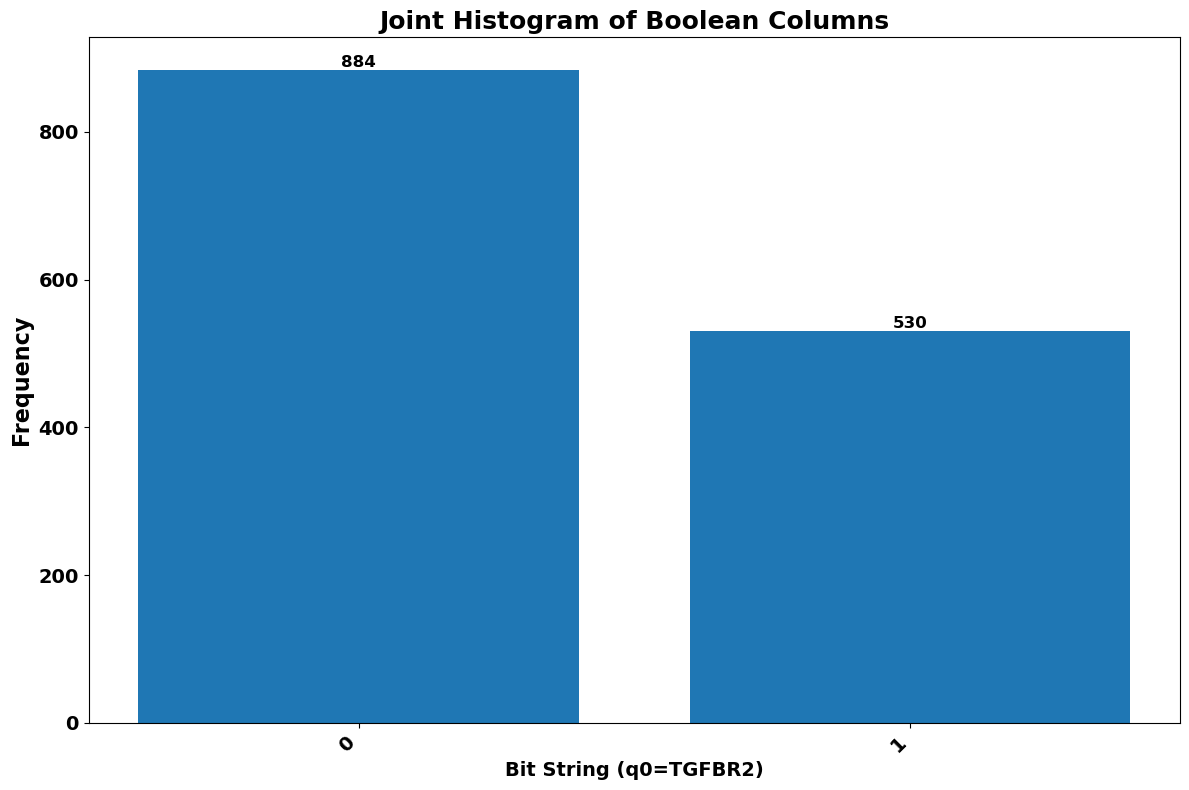

Joint Counts: Counter({'0': 884, '1': 530})


In [10]:
#Xct1_binary_co
#Xct2_binary_co
#Xct1_binary_mo
#Xct2_binary_mo

#joint_counts = count_boolean_vector_occurrences(Xct1_binary_co[:,0])
joint_counts, sorted_bit_strings = create_joint_histogram(np.asarray( [Xct1_binary_co[:,0]] ).T)

act_ct1 = np.asarray([ct1_percentages_co[0]])
num_qubits = 1 
plot_joint_histogram(joint_counts, num_qubits, reverse_bits=True, features=gl_source)  # Pass num_qubits

print("Joint Counts:", joint_counts)

findfont: Font family ['DejaVu Sans Display'] not found. Falling back to DejaVu Sans.


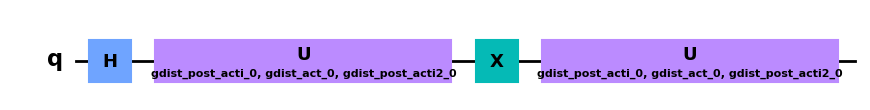

In [11]:
ansatz_grn = create_grn_ansatz(1, "Gdist")
ansatz_grn.draw(output="mpl", style="clifford", fold=40)

In [ ]:
ansatz_grn_m = create_grn_ansatz_measure(1, "Gdist")

static_params, variable_params_dict = create_parameter_dictionaries(ansatz_grn, act_ct1)

x0_initial = np.zeros(len(variable_params_dict))
all_circuit_param_objects = static_params.copy()
all_circuit_param_objects.update(dict(zip(variable_params_dict, x0_initial)))

Interaction observable CT from histogram: SparsePauliOp(['I', 'Z'],
              coeffs=[-707.+0.j, -177.+0.j])
Static Parameters: {Parameter(gdist_act_0): 1.1775418008504883}
Variable Parameters: {Parameter(gdist_post_acti2_0): 0.0, Parameter(gdist_post_acti_0): 0.0}
Starting optimization with method: COBYLA
Iteration 0: Current cost: -706.9999999999998
Iteration 20: Current cost: -769.158281758527

Optimization Result:
 message: Optimization terminated successfully.
 success: True
  status: 1
     fun: -769.1676936239579
       x: [ 3.927e-01  1.047e+00]
    nfev: 39
   maxcv: 0.0

Final Energy: -769.1676936239579

Optimized Full Parameters:
  gdist_act_0: 1.1775418008504883
  gdist_post_acti2_0: 0.39266661302123246
  gdist_post_acti_0: 1.0473844503161933


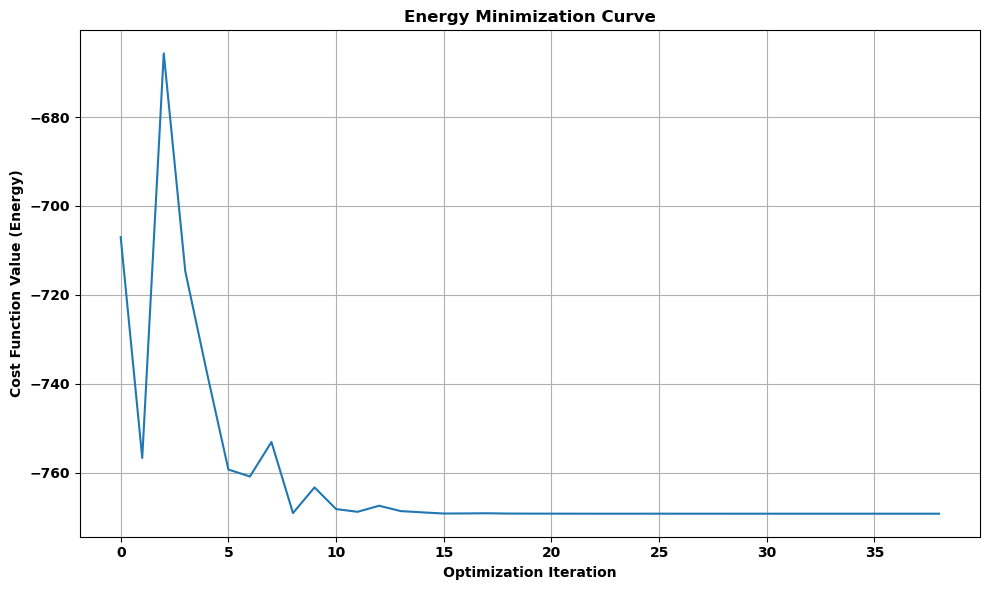

The counts are: {'0': 691, '1': 333}


C:\Users\ssromerogon\Documents\vscode_working_dir\QuantumXCT\python\cc_grn_functions\quantum_functions.py:395: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  plot_histogram(counts, bar_labels=True, title=title).show()


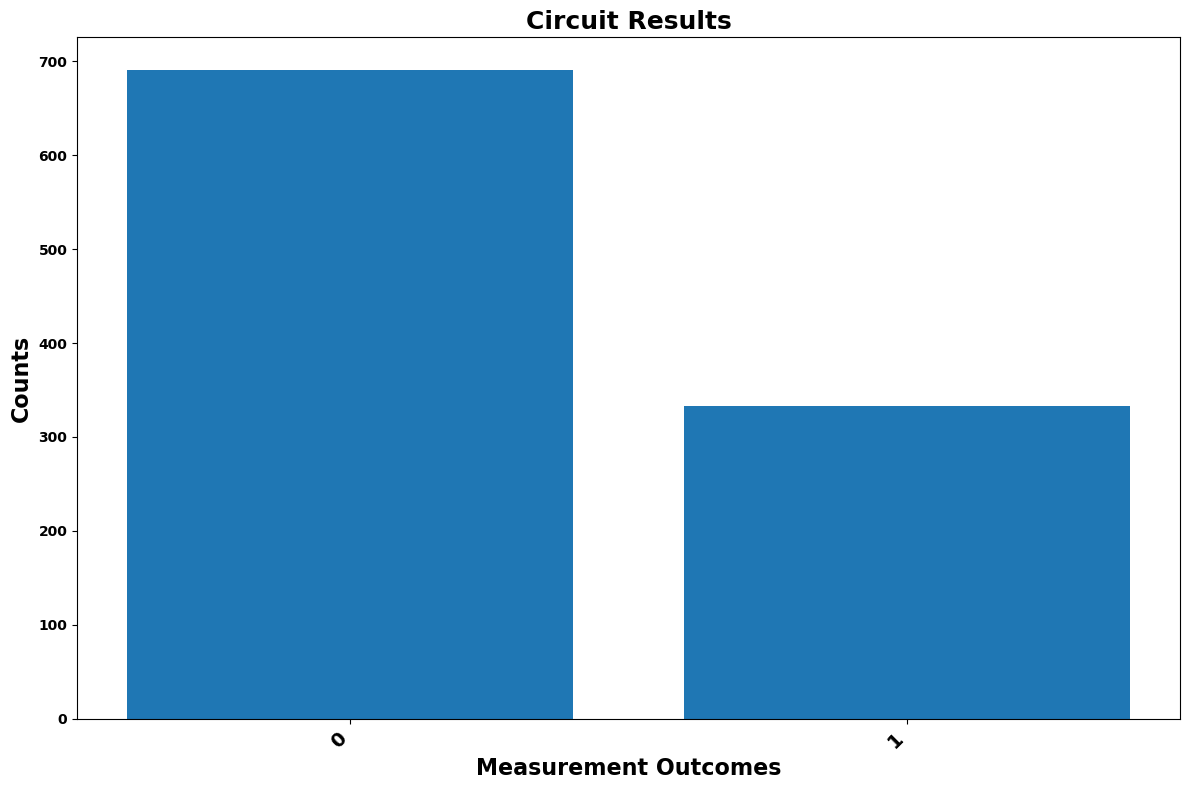

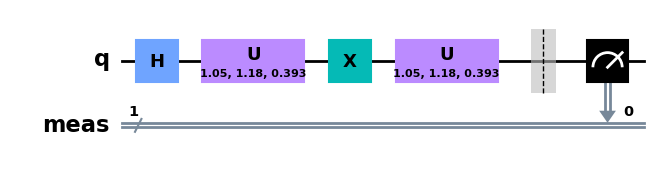

In [13]:
min_ones = 0

result_interaction_bfgs, optimized_full_params, cost_values = vqe_solver(
    joint_counts,
    ansatz_grn, # Renamed from 'cirquit' for common convention
    act_ct1, # Renamed from 'act_percentages' for consistency with create_parameter_dictionaries_cust
    cost_func_wrapper, # This function needs to be defined to accept the correct arguments (see comments below)
    min_ones_obs=min_ones, # Added as an explicit argument for flexibility
    optimizer_method="COBYLA",# COBYLA | L-BFGS-B
)

# Plot the cost function values
plt.figure(figsize=(10, 6))
plt.plot(cost_values)
plt.xlabel("Optimization Iteration")
plt.ylabel("Cost Function Value (Energy)")
plt.title("Energy Minimization Curve")
plt.grid(True)
plt.tight_layout()
plt.show()
counts, bound_circuit = evaluate_and_plot_ansatz(ansatz_grn, optimized_full_params, shots=1024, title="Circuit Results")
bound_circuit.draw(output="mpl", style="clifford", fold=40)  # Show the circuit plot

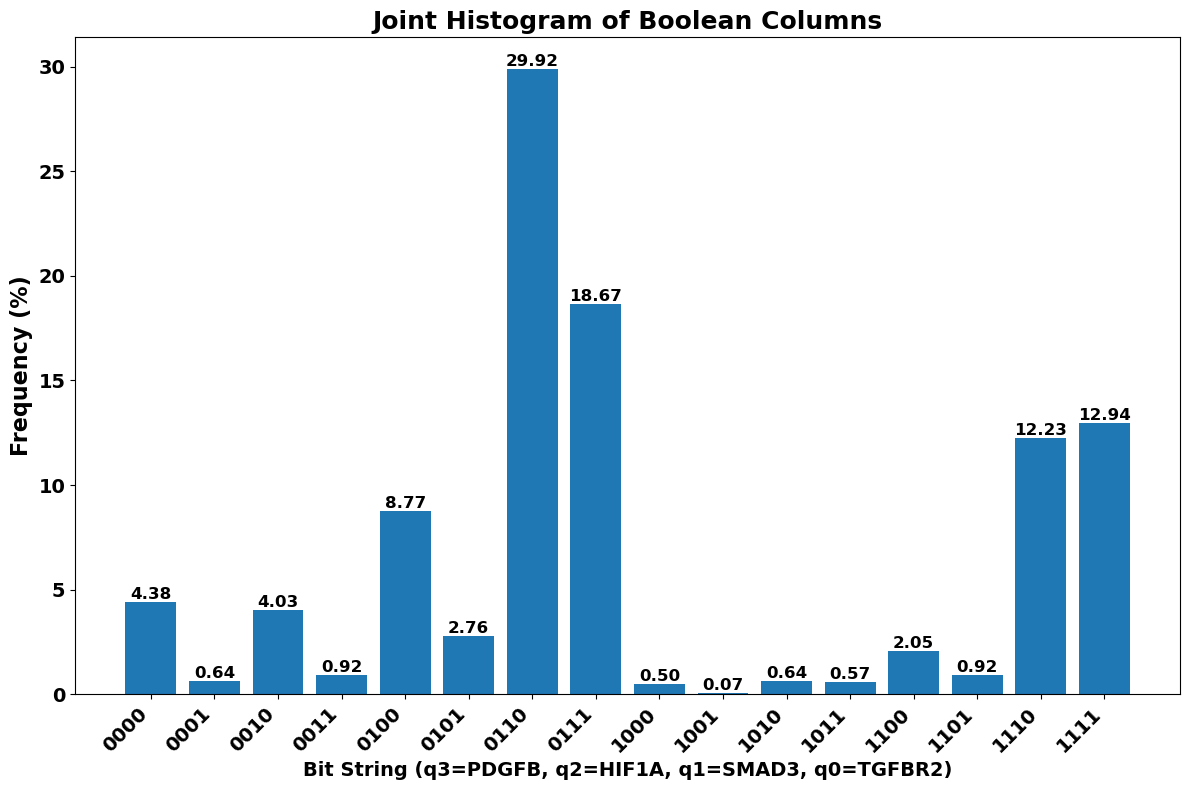

Joint Counts: {'0111': 12.234794908062236, '1110': 18.67043847241867, '0011': 2.050919377652051, '0110': 29.915134370579917, '0000': 4.384724186704385, '0100': 4.031117397454031, '0010': 8.76944837340877, '1101': 0.5657708628005658, '1111': 12.942008486562942, '1000': 0.6364922206506365, '1010': 2.758132956152758, '1100': 0.9193776520509194, '0001': 0.49504950495049505, '1011': 0.9193776520509194, '0101': 0.6364922206506365, '1001': 0.07072135785007072}
Bit Strings: ['0000', '0001', '0010', '0011', '0100', '0101', '0110', '0111', '1000', '1001', '1010', '1011', '1100', '1101', '1110', '1111']


In [14]:
#joint_counts_ct1_co, bit_strings_ct1_co = create_joint_histogram(Xct1_binary_co)
joint_counts_ct1_co, bit_strings_ct1_co = create_percent_joint_histogram(Xct1_binary_co)

num_qubits = Xct1_binary_co.shape[1]  # Get the number of qubits (important!)
plot_joint_histogram(joint_counts_ct1_co, num_qubits, reverse_bits=True, features=gl_source)  # Pass num_qubits

print("Joint Counts:", joint_counts_ct1_co)
print("Bit Strings:", bit_strings_ct1_co)

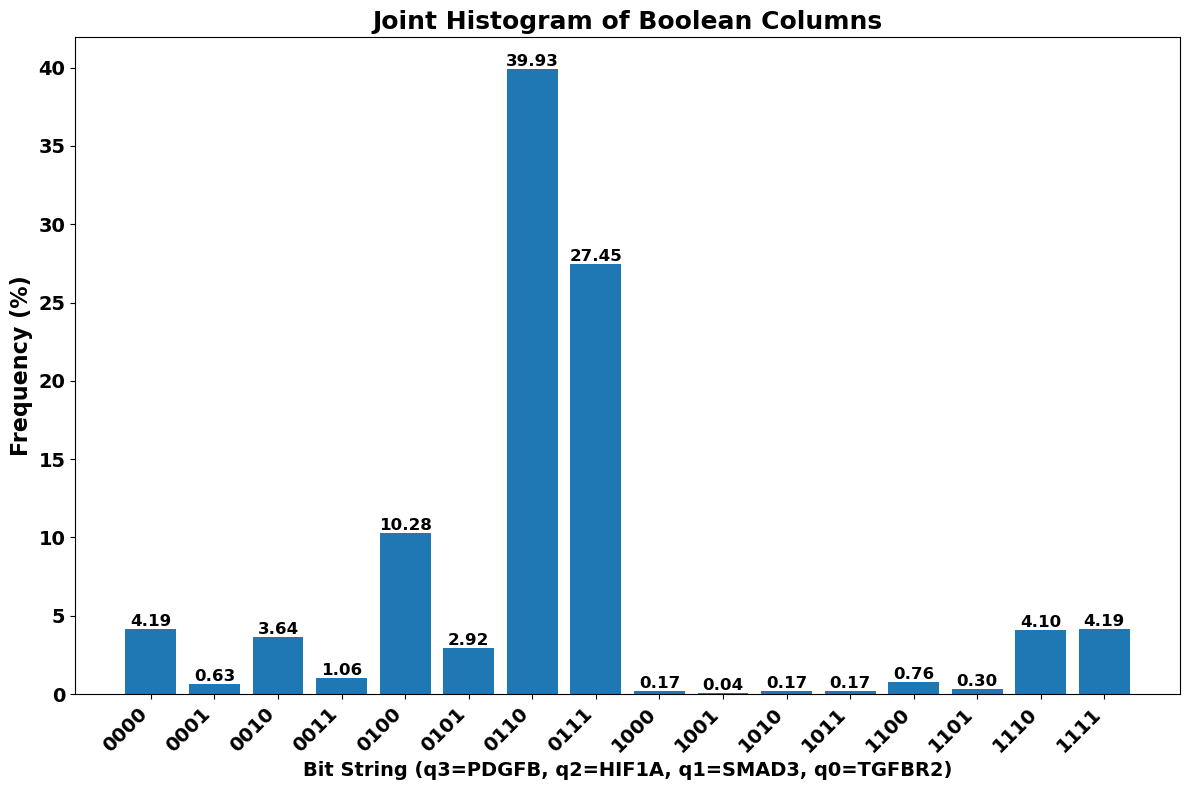

Joint Counts: {'0110': 39.93231810490694, '0010': 10.279187817258883, '0000': 4.187817258883249, '1111': 4.187817258883249, '1110': 27.45346869712352, '0111': 4.103214890016921, '0100': 3.6379018612521152, '1010': 2.918781725888325, '1100': 1.0575296108291032, '0011': 0.7614213197969544, '1000': 0.6345177664974619, '0101': 0.1692047377326565, '1101': 0.1692047377326565, '0001': 0.1692047377326565, '1001': 0.04230118443316413, '1011': 0.2961082910321489}
Bit Strings: ['0000', '0001', '0010', '0011', '0100', '0101', '0110', '0111', '1000', '1001', '1010', '1011', '1100', '1101', '1110', '1111']


In [15]:
#joint_counts_ct1_mo, bit_strings_ct1_mo = create_joint_histogram(Xct1_binary_mo)
joint_counts_ct1_mo, bit_strings_ct1_mo = create_percent_joint_histogram(Xct1_binary_mo)

num_qubits = Xct1_binary_mo.shape[1]  # Get the number of qubits (important!)
plot_joint_histogram(joint_counts_ct1_mo, num_qubits, reverse_bits=True, features=gl_source )  # Pass num_qubits

print("Joint Counts:", joint_counts_ct1_mo)
print("Bit Strings:", bit_strings_ct1_mo)

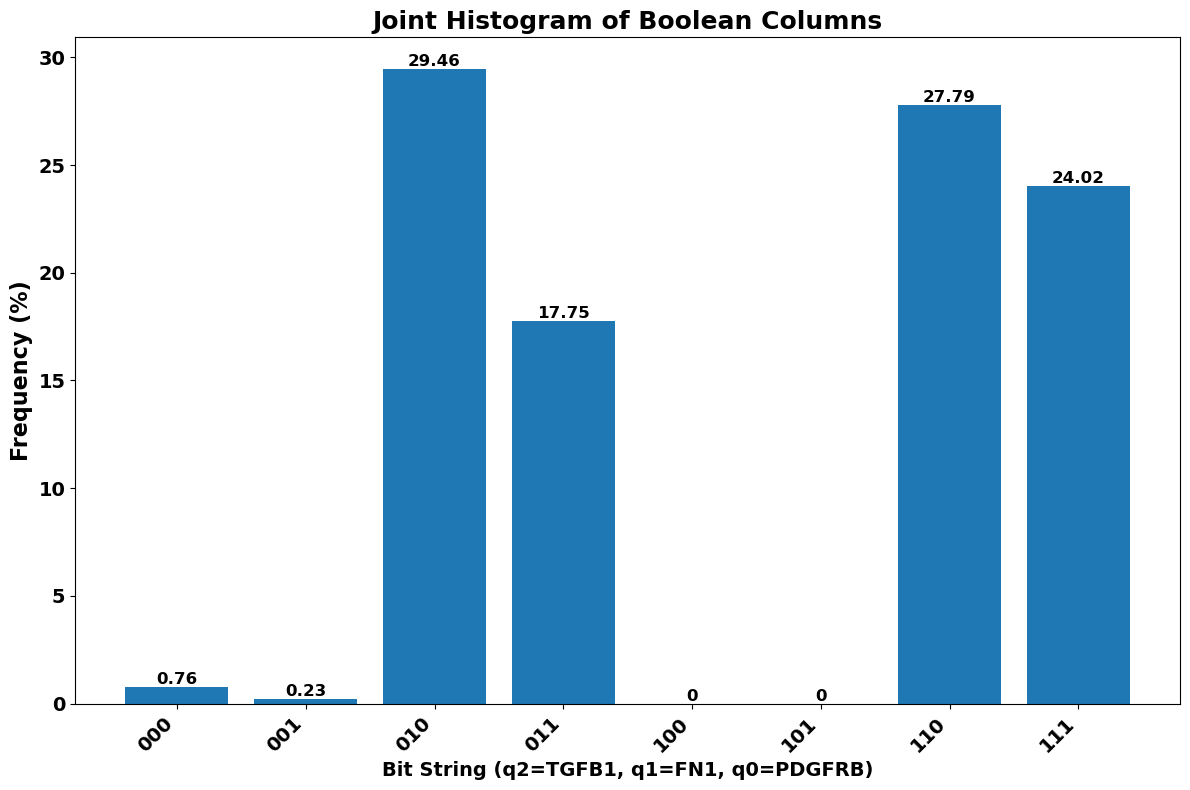

Joint Counts: {'010': 29.45619335347432, '111': 24.018126888217523, '011': 27.794561933534744, '110': 17.749244712990937, '000': 0.7552870090634441, '100': 0.22658610271903326}
Bit Strings: ['000', '010', '011', '100', '110', '111']


In [16]:
#joint_counts_ct2_co, bit_strings_ct2_co = create_joint_histogram(Xct2_binary_co)
joint_counts_ct2_co, bit_strings_ct2_co = create_percent_joint_histogram(Xct2_binary_co)

num_qubits2 = Xct2_binary_co.shape[1]  # Get the number of qubits (important!)
plot_joint_histogram(joint_counts_ct2_co, num_qubits2, reverse_bits=True, features=gl_recv)  # Pass num_qubits

print("Joint Counts:", joint_counts_ct2_co)
print("Bit Strings:", bit_strings_ct2_co)

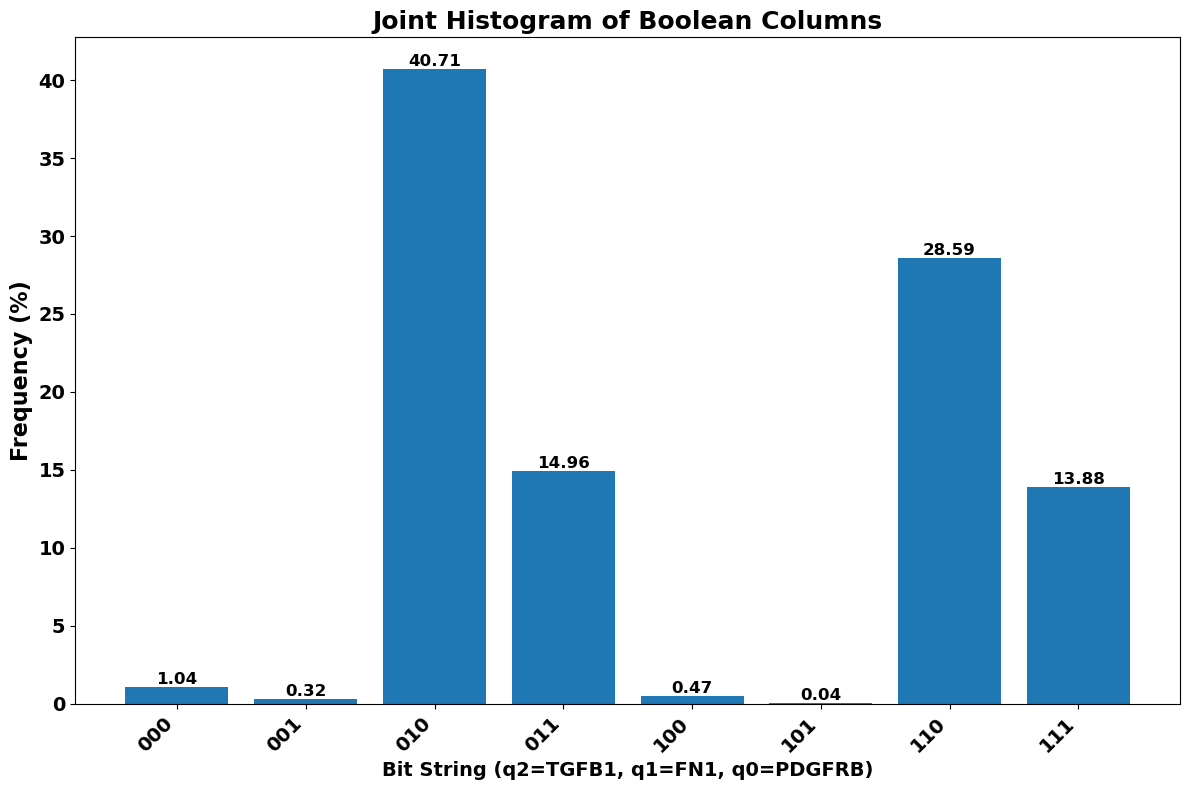

Joint Counts: {'111': 13.880918220946914, '010': 40.71018651362984, '011': 28.586800573888095, '110': 14.956958393113343, '000': 1.0401721664275465, '100': 0.32281205164992827, '001': 0.4662840746054519, '101': 0.03586800573888092}
Bit Strings: ['000', '001', '010', '011', '100', '101', '110', '111']


In [ ]:
#joint_counts_ct2_mo, bit_strings_ct2_mo = create_joint_histogram(Xct2_binary_mo)
joint_counts_ct2_mo, bit_strings_ct2_mo = create_percent_joint_histogram(Xct2_binary_mo)

num_qubits2 = Xct2_binary_mo.shape[1]  # Get the number of qubits (important!)
plot_joint_histogram(joint_counts_ct2_mo, num_qubits2, reverse_bits=True, features=gl_recv)  # Pass num_qubits

print("Joint Counts:", joint_counts_ct2_mo)
print("Bit Strings:", bit_strings_ct2_mo)

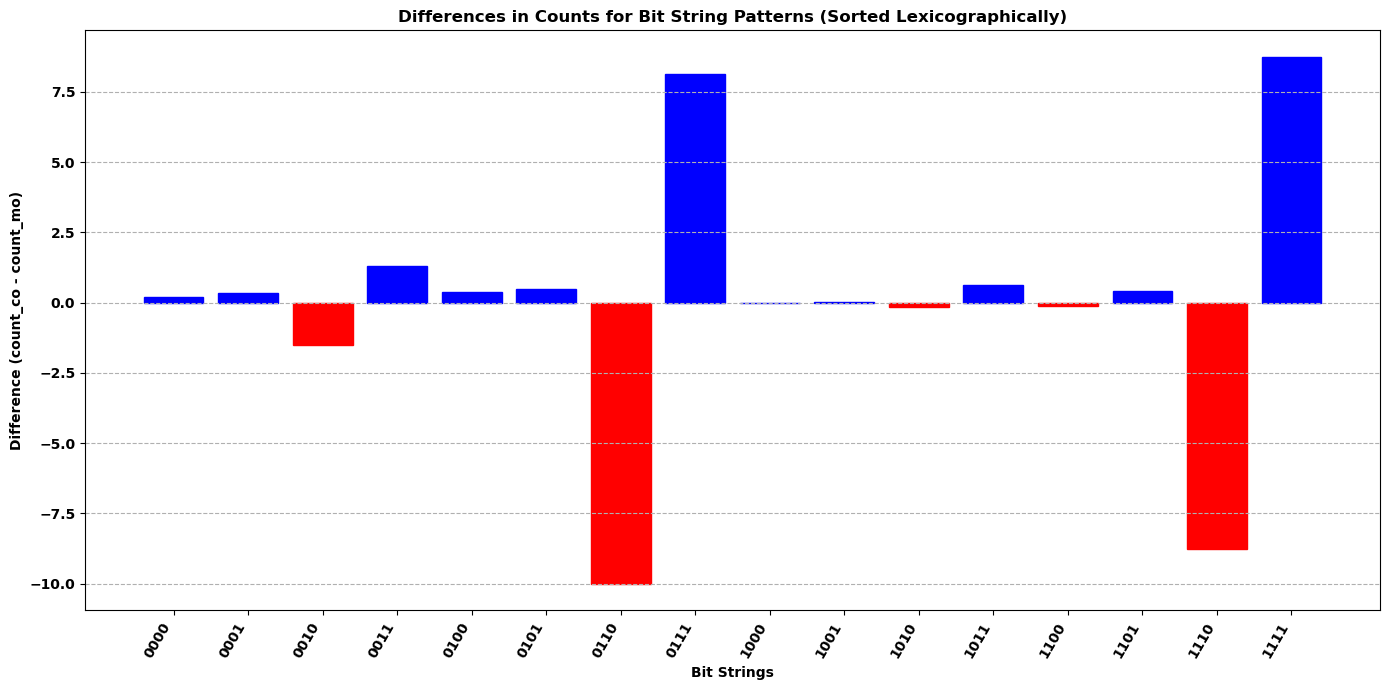

In [56]:
import matplotlib.pyplot as plt
import numpy as np
from collections import Counter # Import Counter

differences_ct1 = {}

# Calculate the differences, handling cases where bitstrings are not common
all_bitstrings = set(joint_counts_ct1_mo.keys()) | set(joint_counts_ct1_co.keys())

for key in all_bitstrings:
    count_co = joint_counts_ct1_co.get(key, 0)
    count_mo = joint_counts_ct1_mo.get(key, 0)
    differences_ct1[key] = count_co - count_mo

# Sort the differences dictionary by the bitstring key (lexicographical order)
# This creates a list of (bitstring, difference) tuples, sorted by the bitstring itself.
differences_ct1 = sorted(differences_ct1.items(), key=lambda item: item[0])
#differences_ct1 = Counter(differences_ct1)

# Separate the sorted bitstrings and their differences into two lists for plotting
sorted_bitstrings = [item[0] for item in differences_ct1]
sorted_diff_values = [item[1] for item in differences_ct1]

# Create the bar plot
plt.figure(figsize=(14, 7)) # Increased figure size for better readability
bars = plt.bar(sorted_bitstrings, sorted_diff_values, edgecolor='black')

# Color the bars based on the difference value
for bar, diff in zip(bars, sorted_diff_values):
    if diff > 0:
        bar.set_color('blue')  # Color for positive differences
    elif diff < 0:
        bar.set_color('red')   # Color for negative differences
    else: # This case is for diff == 0
        bar.set_color('skyblue') # A distinct color for zero differences

plt.xlabel('Bit Strings')
plt.ylabel('Difference (count_co - count_mo)') # Updated ylabel for clarity
plt.title('Differences in Counts for Bit String Patterns (Sorted Lexicographically)') # Updated title
plt.xticks(rotation=60, ha='right') # Rotate labels more for potentially long bitstrings
plt.tight_layout() # Adjust layout to prevent labels from overlapping
plt.grid(axis='y', linestyle='--')
plt.show()

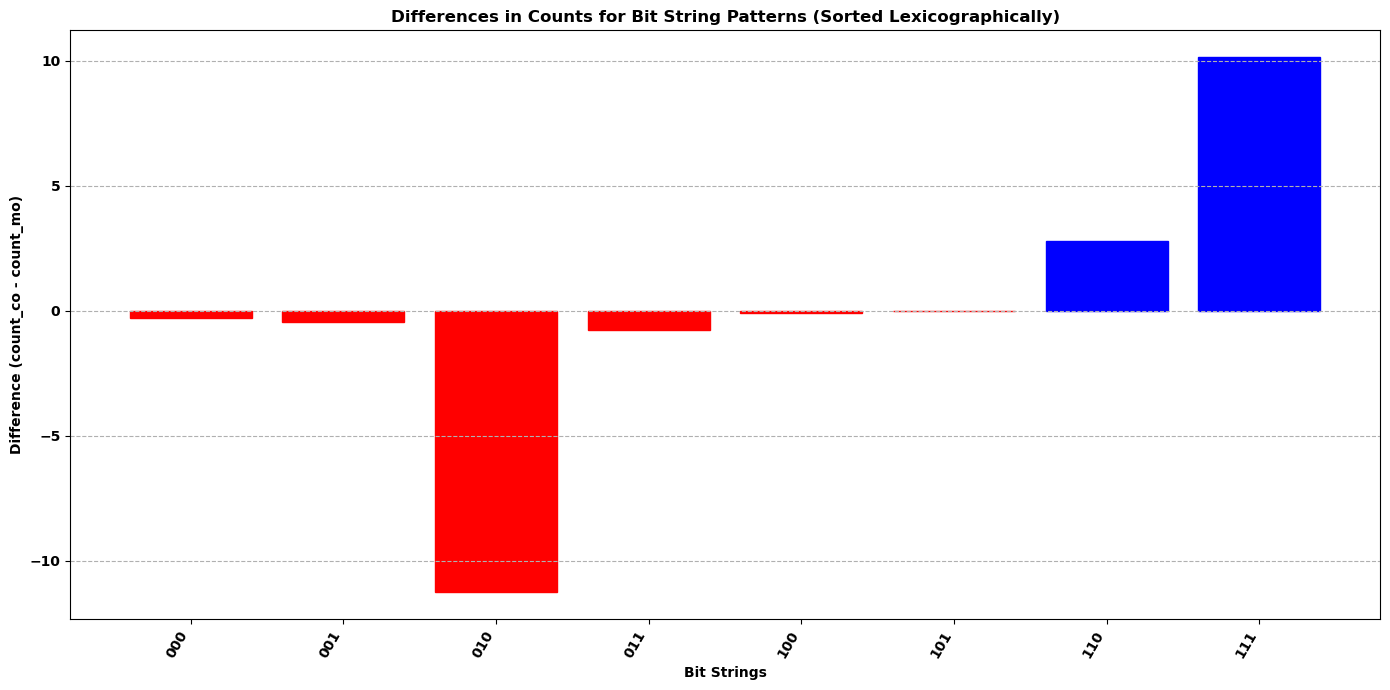

In [83]:
import matplotlib.pyplot as plt
import numpy as np
from collections import Counter # Import Counter

differences_ct2 = {}

# Calculate the differences, handling cases where bitstrings are not common
all_bitstrings = set(joint_counts_ct2_mo.keys()) | set(joint_counts_ct2_co.keys())

for key in all_bitstrings:
    count_co = joint_counts_ct2_co.get(key, 0)
    count_mo = joint_counts_ct2_mo.get(key, 0)
    differences_ct2[key] = count_co - count_mo
    

# Sort the differences dictionary by the bitstring key (lexicographical order)
# This creates a list of (bitstring, difference) tuples, sorted by the bitstring itself.
differences_ct2 = sorted(differences_ct2.items(), key=lambda item: item[0])
#differences_ct2 = Counter(differences_ct2)

# Separate the sorted bitstrings and their differences into two lists for plotting
sorted_bitstrings = [item[0] for item in differences_ct2]
sorted_diff_values = [item[1] for item in differences_ct2]

# Create the bar plot
plt.figure(figsize=(14, 7)) # Increased figure size for better readability
bars = plt.bar(sorted_bitstrings, sorted_diff_values, edgecolor='black')

# Color the bars based on the difference value
for bar, diff in zip(bars, sorted_diff_values):
    if diff > 0:
        bar.set_color('blue')  # Color for positive differences
    elif diff < 0:
        bar.set_color('red')   # Color for negative differences
    else: # This case is for diff == 0
        bar.set_color('skyblue') # A distinct color for zero differences

plt.xlabel('Bit Strings')
plt.ylabel('Difference (count_co - count_mo)') # Updated ylabel for clarity
plt.title('Differences in Counts for Bit String Patterns (Sorted Lexicographically)') # Updated title
plt.xticks(rotation=60, ha='right') # Rotate labels more for potentially long bitstrings
plt.tight_layout() # Adjust layout to prevent labels from overlapping
plt.grid(axis='y', linestyle='--')
plt.show()

In [42]:
import sys
import os

# Replace with your actual path
cc_grn_functions_path = r"C:\Users\ssromerogon\Documents\vscode_working_dir\QuantumXCT\python\cc_grn_functions"
sys.path.append(cc_grn_functions_path)

from quantum_functions import create_grn_ansatz, create_interaction_observable_from_histogram, evaluate_and_plot_ansatz
from quantum_functions import create_parameter_dictionaries, cost_func_vqe, cost_func_wrapper
from quantum_functions import create_interaction_observable_general, create_parameter_dictionaries_from_circuit, create_joint_circuit_from_ansatzes, vqe_solver, vqe_lr_solver
import matplotlib.pyplot as plt

Interaction observable CT from histogram: SparsePauliOp(['IIIZ', 'IIZI', 'IIZZ', 'IZII', 'IZIZ', 'IZZI', 'IZZZ', 'ZIII', 'ZIIZ', 'ZIZI', 'ZIZZ', 'ZZII', 'ZZIZ', 'ZZZI', 'ZZZZ'],
              coeffs=[ 2.50208215+0.j, -0.20900794+0.j, -2.40656045+0.j, -0.09944069+0.j,
 -2.03476475+0.j,  0.17016205+0.j,  1.97808894+0.j,  0.0903238 +0.j,
  0.14179423+0.j, -0.22712954+0.j, -0.18656348+0.j, -0.06651068+0.j,
  0.12293221+0.j,  0.08022716+0.j, -0.05253993+0.j])
Static Parameters: {Parameter(ct1_act_0): 0.022700846548656672, Parameter(ct1_act_1): -0.024992171541851516, Parameter(ct1_act_2): -0.05252942433127039, Parameter(ct1_act_3): 0.6288418325047554}
Variable Parameters: {Parameter(ct1_grn_0_1): 0.0, Parameter(ct1_grn_0_2): 0.0, Parameter(ct1_grn_0_3): 0.0, Parameter(ct1_grn_1_0): 0.0, Parameter(ct1_grn_1_2): 0.0, Parameter(ct1_grn_1_3): 0.0, Parameter(ct1_grn_2_0): 0.0, Parameter(ct1_grn_2_1): 0.0, Parameter(ct1_grn_2_3): 0.0, Parameter(ct1_grn_3_0): 0.0, Parameter(ct1_grn_3_1): 0.0, Param

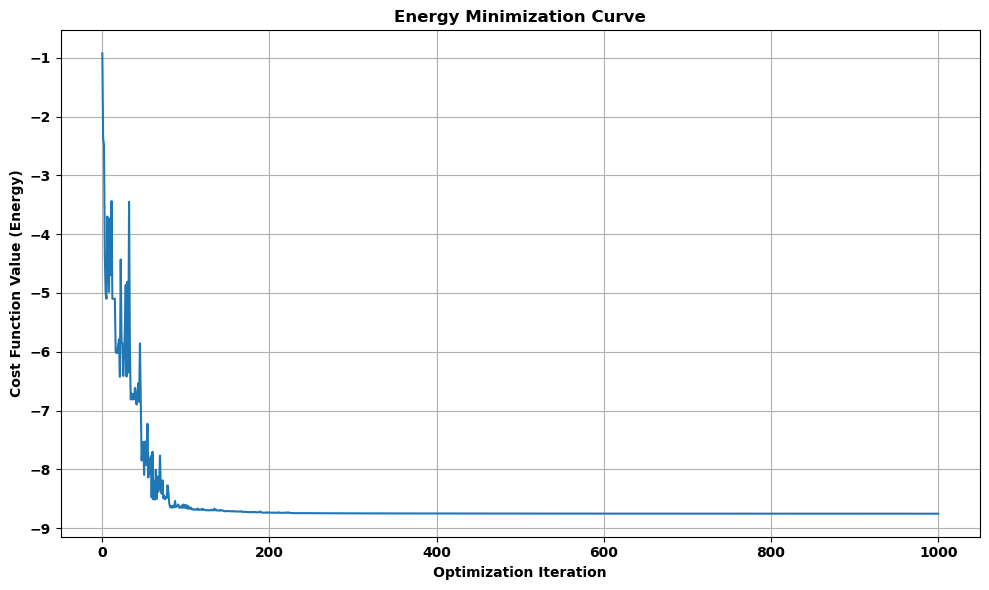

The counts are: {'1111': 1023, '0111': 1}


C:\Users\ssromerogon\Documents\vscode_working_dir\QuantumXCT\python\cc_grn_functions\quantum_functions.py:395: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  plot_histogram(counts, bar_labels=True, title=title).show()


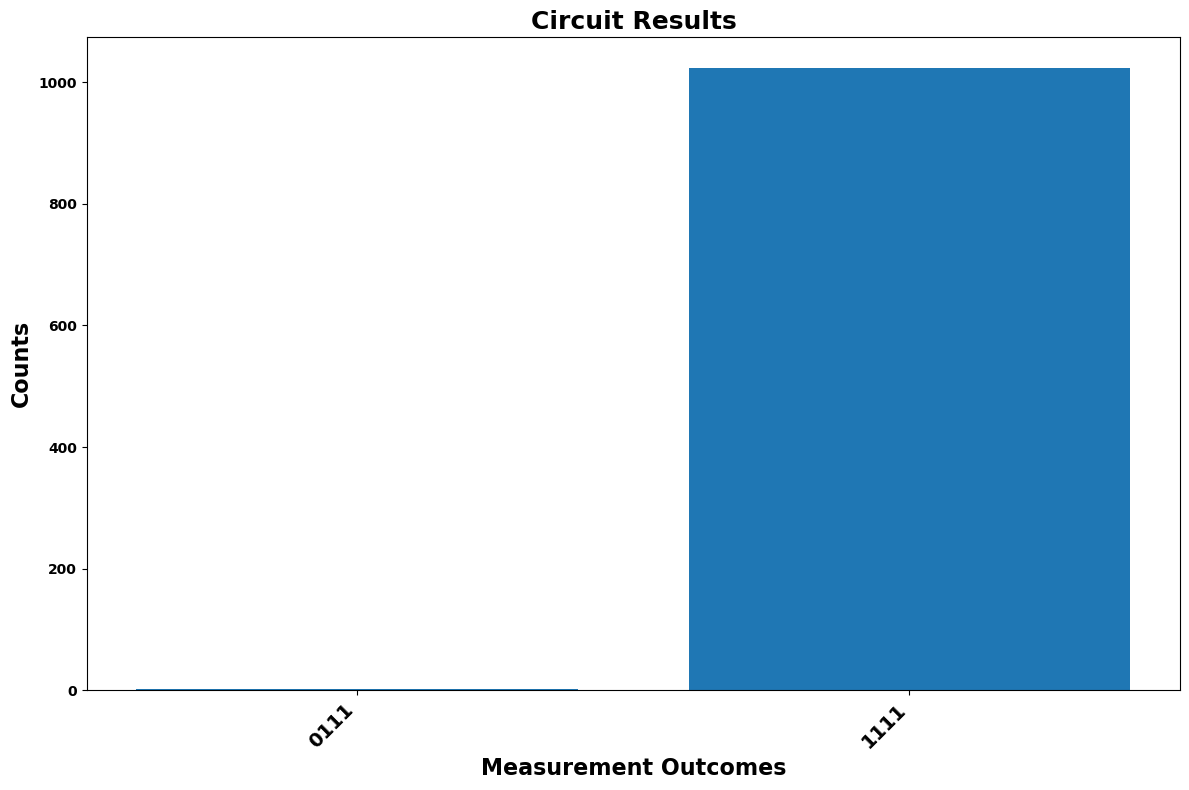

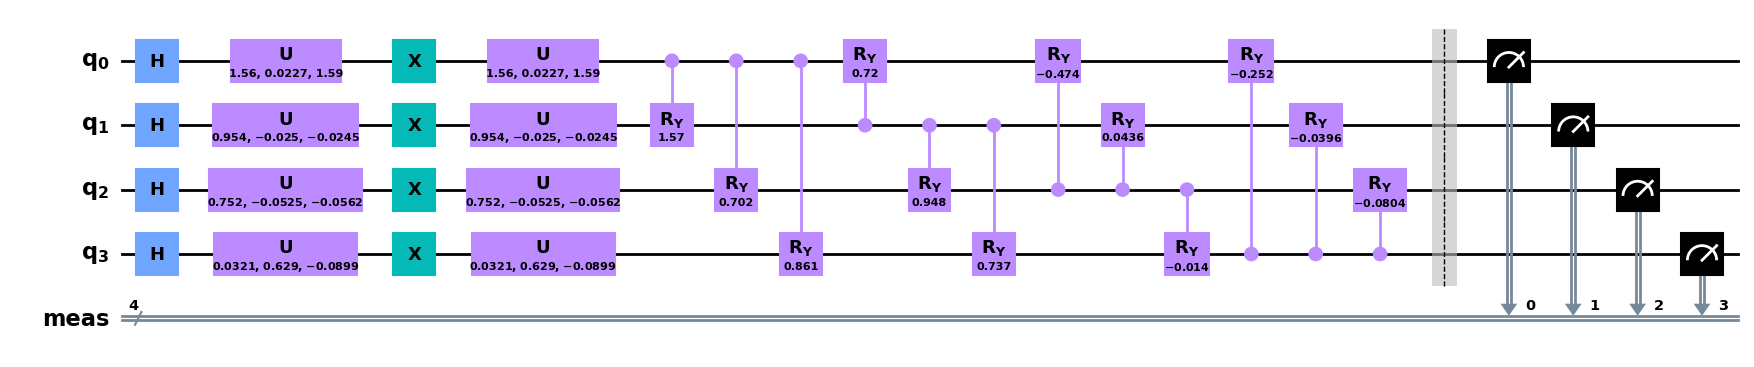

In [89]:
ng_ct1 = len(gl_source)  # Assuming gl_source is defined elsewhere
ansatz_grn_ct1 = create_grn_ansatz(ng_ct1, "CT1")

min_ones = 0
ct1_percentages = ct1_percentages_co - ct1_percentages_mo
differences_ct1 = dict(differences_ct1)

result_interaction_bfgs, optimized_full_params_ct1, cost_values = vqe_solver(
    differences_ct1,
    ansatz_grn_ct1, # Renamed from 'cirquit' for common convention
    ct1_percentages, # Renamed from 'act_percentages' for consistency with create_parameter_dictionaries_cust
    cost_func_wrapper, # This function needs to be defined to accept the correct arguments (see comments below)
    min_ones_obs=min_ones, # Added as an explicit argument for flexibility
    optimizer_method="COBYLA",# COBYLA | L-BFGS-B
)

# Plot the cost function values
plt.figure(figsize=(10, 6))
plt.plot(cost_values)
plt.xlabel("Optimization Iteration")
plt.ylabel("Cost Function Value (Energy)")
plt.title("Energy Minimization Curve")
plt.grid(True)
plt.tight_layout()
plt.show()
counts, bound_circuit = evaluate_and_plot_ansatz(ansatz_grn_ct1, optimized_full_params_ct1, shots=1024, title="Circuit Results")
bound_circuit.draw(output="mpl", style="clifford", fold=40)  # Show the circuit plot

Interaction observable CT from histogram: SparsePauliOp(['IIZ', 'IZI', 'IZZ', 'ZII', 'ZIZ', 'ZZI', 'ZZZ'],
              coeffs=[ 2.21070449+0.j,  0.2208158 +0.j, -2.24096473+0.j,  3.19935026+0.j,
  0.35938441+0.j, -3.04458144+0.j, -0.41982363+0.j])
Static Parameters: {Parameter(ct2_act_0): 0.4020422106867664, Parameter(ct2_act_1): 0.02774853138332478, Parameter(ct2_act_2): 0.27780531897985483}
Variable Parameters: {Parameter(ct2_grn_0_1): 0.0, Parameter(ct2_grn_0_2): 0.0, Parameter(ct2_grn_1_0): 0.0, Parameter(ct2_grn_1_2): 0.0, Parameter(ct2_grn_2_0): 0.0, Parameter(ct2_grn_2_1): 0.0, Parameter(ct2_post_acti2_0): 0.0, Parameter(ct2_post_acti2_1): 0.0, Parameter(ct2_post_acti2_2): 0.0, Parameter(ct2_post_acti_0): 0.0, Parameter(ct2_post_acti_1): 0.0, Parameter(ct2_post_acti_2): 0.0}
Starting optimization with method: COBYLA
Iteration 0: Current cost: -1.0357584421401271
Iteration 20: Current cost: -7.224729783255665
Iteration 40: Current cost: -9.761906250211142
Iteration 60: Current 

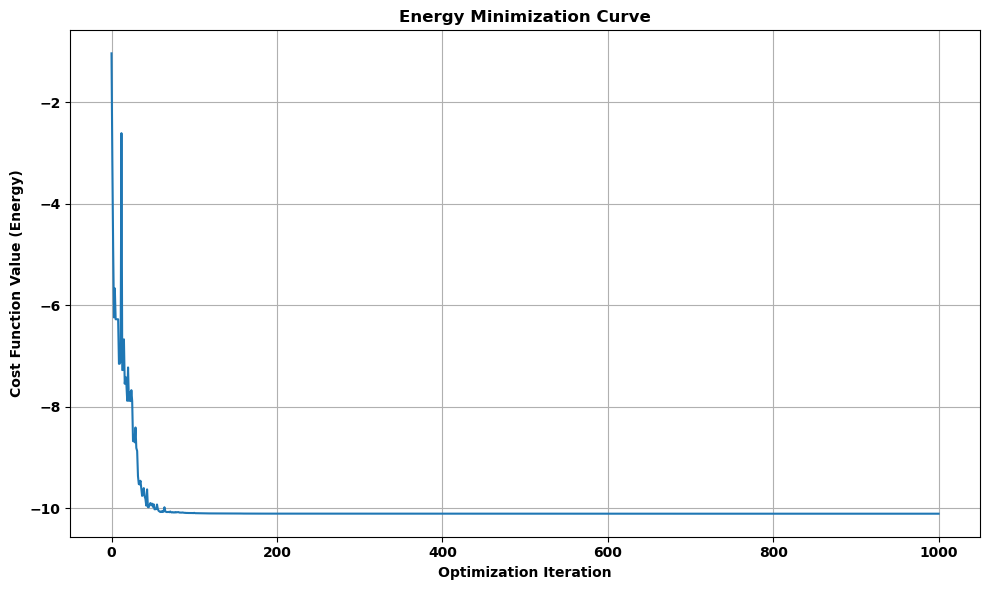

The counts are: {'111': 1022, '110': 1, '000': 1}


C:\Users\ssromerogon\Documents\vscode_working_dir\QuantumXCT\python\cc_grn_functions\quantum_functions.py:395: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  plot_histogram(counts, bar_labels=True, title=title).show()


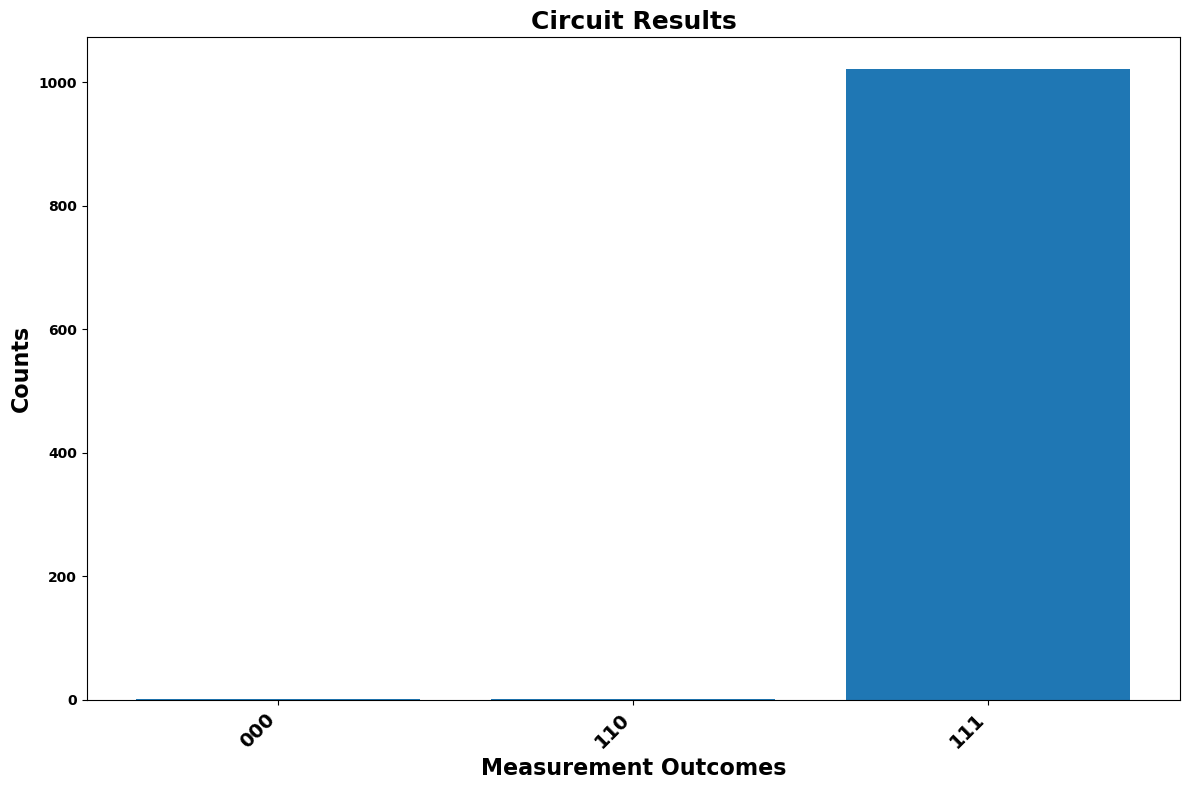

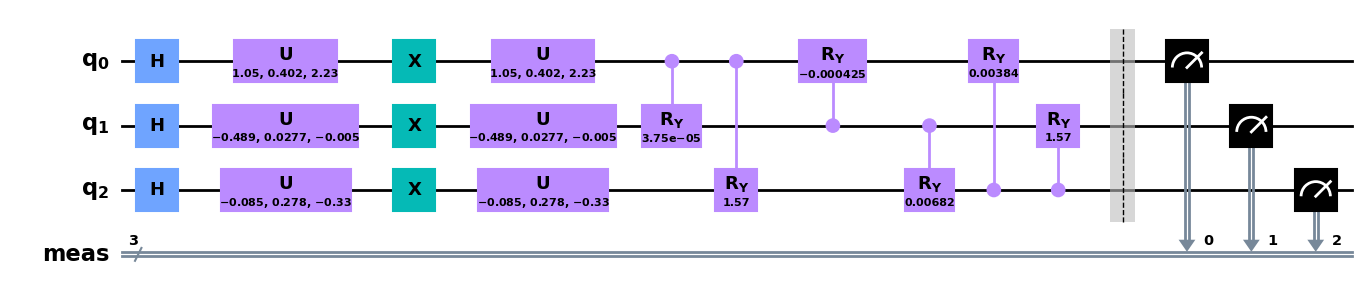

In [90]:
ng_ct2 = len(gl_recv)  # Assuming gl_source is defined elsewhere
ansatz_grn_ct2 = create_grn_ansatz(ng_ct2, "CT2")

min_ones = 0
ct2_percentages = ct2_percentages_co - ct2_percentages_mo
differences_ct2 = dict(differences_ct2)

result_interaction_bfgs, optimized_full_params_ct2, cost_values = vqe_solver(
    differences_ct2,
    ansatz_grn_ct2, # Renamed from 'cirquit' for common convention
    ct2_percentages, # Renamed from 'act_percentages' for consistency with create_parameter_dictionaries_cust
    cost_func_wrapper, # This function needs to be defined to accept the correct arguments (see comments below)
    min_ones_obs=min_ones, # Added as an explicit argument for flexibility
    optimizer_method="COBYLA",# COBYLA | L-BFGS-B
)

# Plot the cost function values
plt.figure(figsize=(10, 6))
plt.plot(cost_values)
plt.xlabel("Optimization Iteration")
plt.ylabel("Cost Function Value (Energy)")
plt.title("Energy Minimization Curve")
plt.grid(True)
plt.tight_layout()
plt.show()
counts, bound_circuit = evaluate_and_plot_ansatz(ansatz_grn_ct2, optimized_full_params_ct2, shots=1024, title="Circuit Results")
bound_circuit.draw(output="mpl", style="clifford", fold=40)  # Show the circuit plot

--- Starting VQE LR Solver ---
Initial combined parameters for LR optimization: {Parameter(ct1_act_0): 0.022700846548656672, Parameter(ct1_act_1): -0.024992171541851516, Parameter(ct1_act_2): -0.05252942433127039, Parameter(ct1_act_3): 0.6288418325047554, Parameter(ct1_grn_0_1): 1.5677136955381252, Parameter(ct1_grn_0_2): 0.7018861094721282, Parameter(ct1_grn_0_3): 0.8608213119461825, Parameter(ct1_grn_1_0): 0.720450386278414, Parameter(ct1_grn_1_2): 0.9480262126624618, Parameter(ct1_grn_1_3): 0.7373125473817254, Parameter(ct1_grn_2_0): -0.473799424936278, Parameter(ct1_grn_2_1): 0.04363130771279083, Parameter(ct1_grn_2_3): -0.014026735689728806, Parameter(ct1_grn_3_0): -0.25201723389457314, Parameter(ct1_grn_3_1): -0.039591375912356064, Parameter(ct1_grn_3_2): -0.08041027337015644, Parameter(ct1_post_acti2_0): 1.5935699643991734, Parameter(ct1_post_acti2_1): -0.024522228464459898, Parameter(ct1_post_acti2_2): -0.05619631299081514, Parameter(ct1_post_acti2_3): -0.08991825572515065, Par

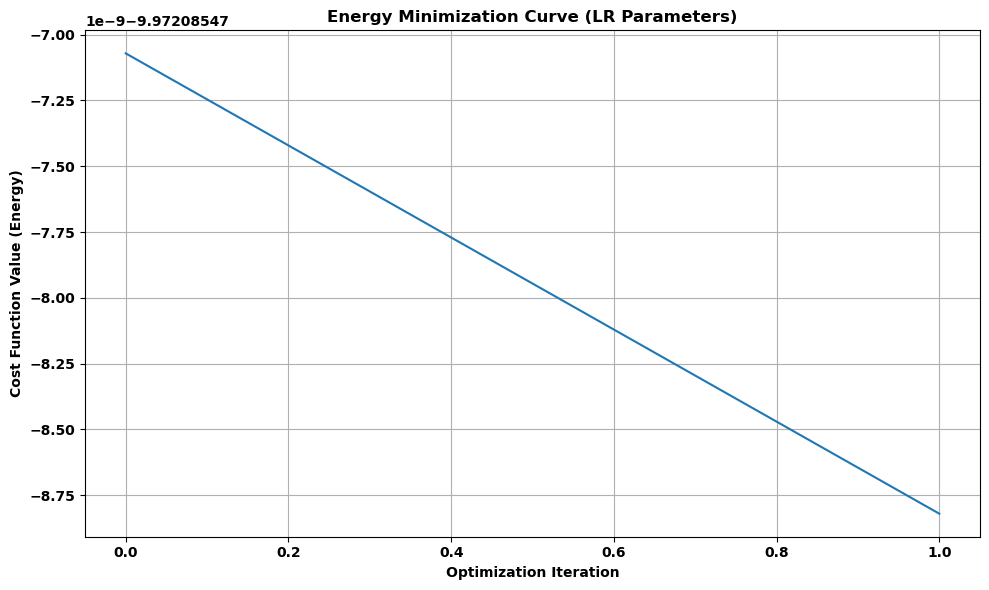

NameError: name 'cc_grn_circuit_co' is not defined

In [ ]:
interactions_lr = {
    (ng_ct1 + ng_ct2 - 1, 0): 10,
}
cc_grn_lr_circuit = create_joint_circuit_from_ansatzes(ansatz_grn_ct1, ansatz_grn_ct2, interactions = interactions_lr)

# --- Calling the vqe_lr_solver function with your variables ---
print("--- Starting VQE LR Solver ---")
result_lr_bfgs, optimized_full_params_lr, cost_values_from_solver = vqe_lr_solver(
    cc_grn_lr_circuit,
    optimized_full_params_ct1,
    optimized_full_params_ct2,
    interactions_lr,
    ansatz_grn_ct1.num_qubits,
    ansatz_grn_ct2.num_qubits,
    cost_func_wrapper,
    create_parameter_dictionaries_from_circuit,
    create_interaction_observable_general
)

print("\n--- VQE LR Solver Completed ---")
print("Final optimized parameters:", optimized_full_params_lr)

# --- Plotting the cost values ---
plt.figure(figsize=(10, 6))
plt.plot(cost_values_from_solver)
plt.xlabel("Optimization Iteration")
plt.ylabel("Cost Function Value (Energy)")
plt.title("Energy Minimization Curve (LR Parameters)")
plt.grid(True)
plt.tight_layout()
plt.show()
counts_cc_grn_co, bound_circuit = evaluate_and_plot_ansatz(cc_grn_lr_circuit, optimized_full_params_lr, shots=1024, title="Circuit Results")
bound_circuit.draw(output="mpl", style="clifford", fold=40)  # Show the circuit plot

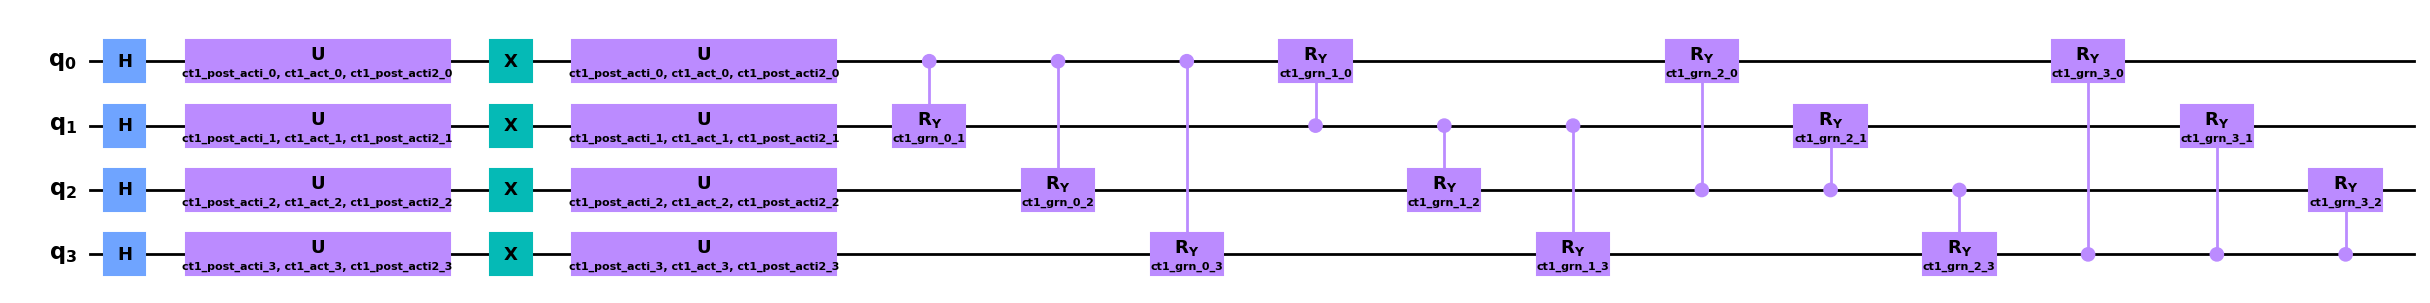

In [17]:
ng_ct1 = len(gl_source)  # Assuming gl_source is defined elsewhere
# Create mono coltured grn
ansatz_grn_ct1_mo = create_grn_ansatz(ng_ct1, "CT1")
# Create co cultured grn
ansatz_grn_ct1_co = create_grn_ansatz(ng_ct1, "CT1")
ansatz_grn_ct1_mo.draw(output="mpl", style="clifford", fold=40)

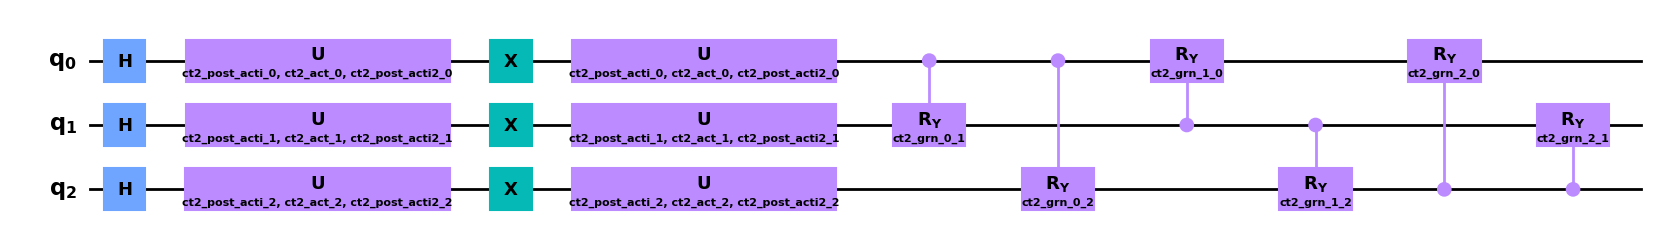

In [18]:
ng_ct2 = len(gl_recv)  #Example for a second cell type
# Create mo cultured grn
ansatz_grn_ct2_mo = create_grn_ansatz(ng_ct2, "CT2")
# Create co cultured grn
ansatz_grn_ct2_co = create_grn_ansatz(ng_ct2, "CT2")
ansatz_grn_ct2_mo.draw(output="mpl", style="clifford", fold=40)

Interaction observable CT from histogram: SparsePauliOp(['IIII', 'IIIZ', 'IIZI', 'IIZZ', 'IZII', 'IZIZ', 'IZZI', 'IZZZ', 'ZIII', 'ZIIZ', 'ZIZI', 'ZIZZ', 'ZZII', 'ZZIZ', 'ZZZI', 'ZZZZ'],
              coeffs=[-6.25      +0.j, -2.5106082 +0.j,  4.78253182+0.j,  1.48514851+0.j,
  3.7393918 +0.j,  0.88401697+0.j, -3.66867044+0.j, -0.97241867+0.j,
 -1.56471004+0.j, -1.44978784+0.j,  0.64533239+0.j,  0.65417256+0.j,
  0.15028289+0.j,  0.42432815+0.j, -0.27404526+0.j, -0.45968883+0.j])
Static Parameters: {Parameter(ct1_act_0): 1.1775418008504883, Parameter(ct1_act_1): 2.51060799049255, Parameter(ct1_act_2): 2.7727776744554893, Parameter(ct1_act_3): 0.9398116636976538}
Variable Parameters: {Parameter(ct1_grn_0_1): 0.0, Parameter(ct1_grn_0_2): 0.0, Parameter(ct1_grn_0_3): 0.0, Parameter(ct1_grn_1_0): 0.0, Parameter(ct1_grn_1_2): 0.0, Parameter(ct1_grn_1_3): 0.0, Parameter(ct1_grn_2_0): 0.0, Parameter(ct1_grn_2_1): 0.0, Parameter(ct1_grn_2_3): 0.0, Parameter(ct1_grn_3_0): 0.0, Parameter(ct1_grn_

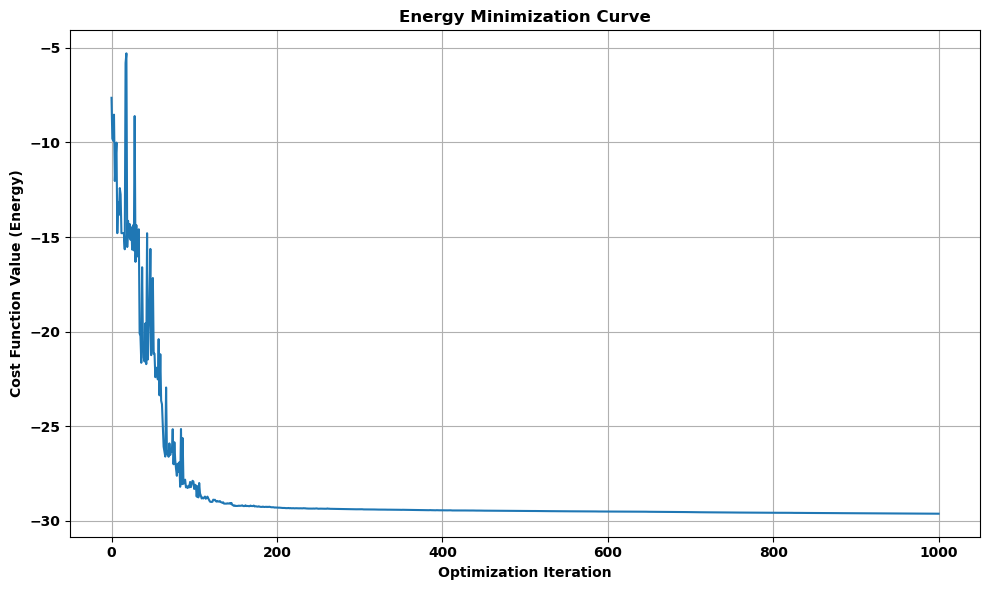

The counts are: {'0110': 1012, '1010': 6, '0010': 2, '1110': 1, '0100': 3}


C:\Users\ssromerogon\Documents\vscode_working_dir\QuantumXCT\python\cc_grn_functions\quantum_functions.py:395: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  plot_histogram(counts, bar_labels=True, title=title).show()


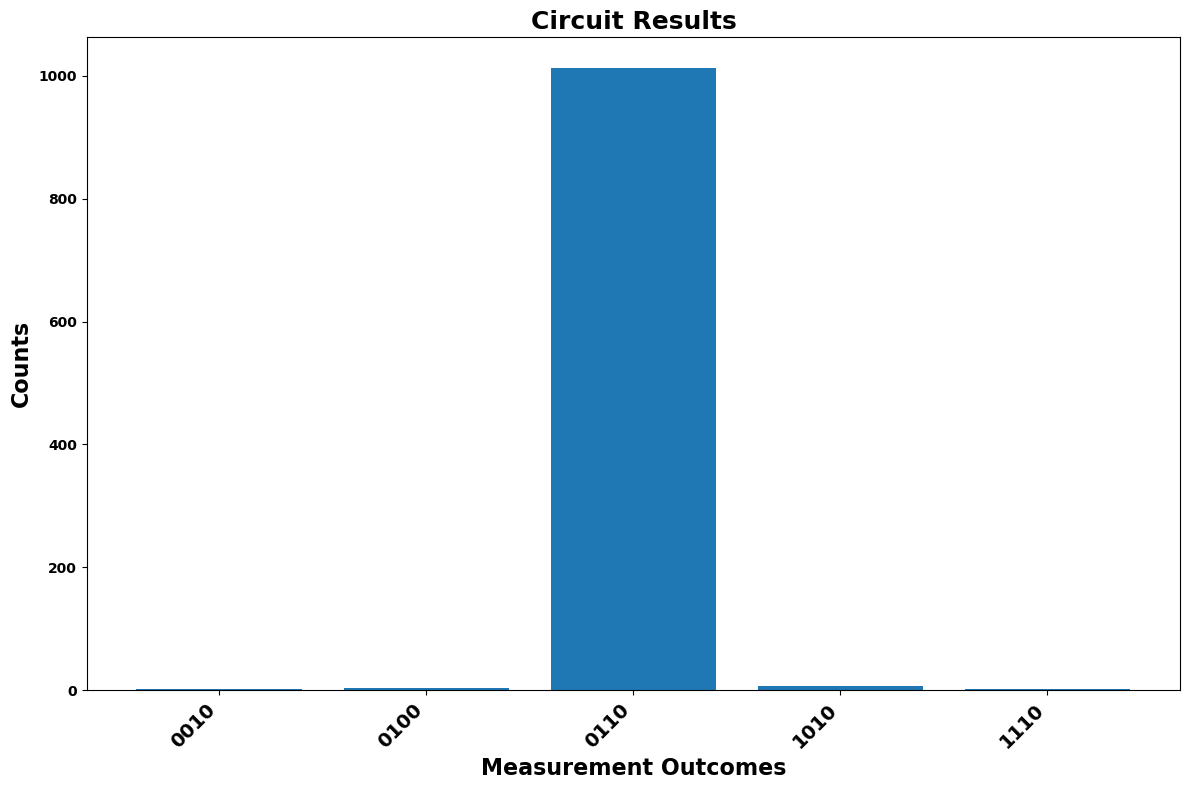

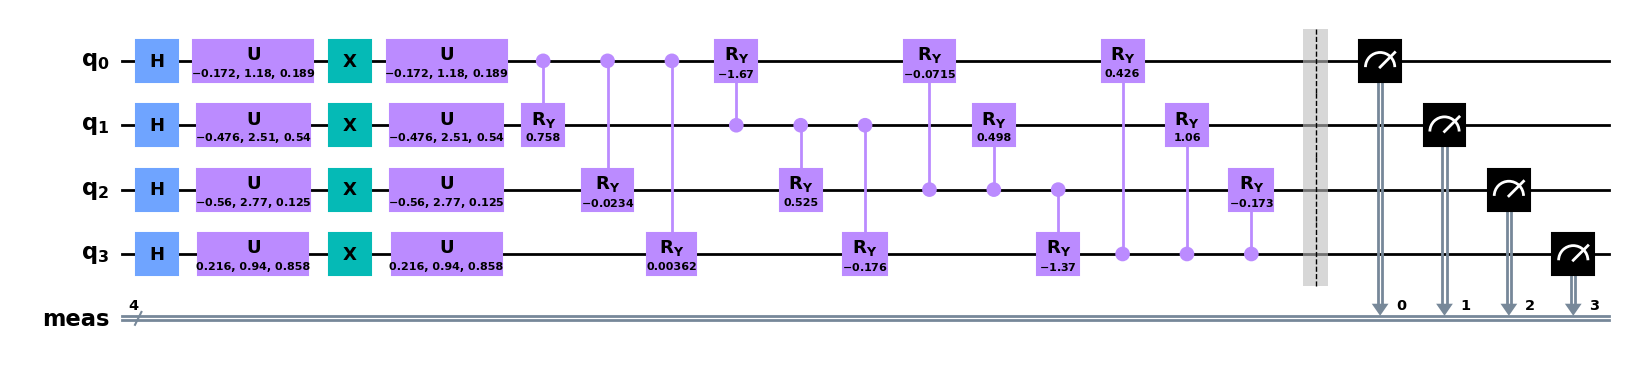

In [19]:
min_ones = 0

result_interaction_bfgs, optimized_full_params_ct1_co, cost_values = vqe_solver(
    joint_counts_ct1_co,
    ansatz_grn_ct1_co, # Renamed from 'cirquit' for common convention
    ct1_percentages_co, # Renamed from 'act_percentages' for consistency with create_parameter_dictionaries_cust
    cost_func_wrapper, # This function needs to be defined to accept the correct arguments (see comments below)
    min_ones_obs=min_ones, # Added as an explicit argument for flexibility
    optimizer_method="COBYLA",# COBYLA | L-BFGS-B
)

# Plot the cost function values
plt.figure(figsize=(10, 6))
plt.plot(cost_values)
plt.xlabel("Optimization Iteration")
plt.ylabel("Cost Function Value (Energy)")
plt.title("Energy Minimization Curve")
plt.grid(True)
plt.tight_layout()
plt.show()
counts, bound_circuit = evaluate_and_plot_ansatz(ansatz_grn_ct1_co, optimized_full_params_ct1_co, shots=1024, title="Circuit Results")
bound_circuit.draw(output="mpl", style="clifford", fold=40)  # Show the circuit plot

Interaction observable CT from histogram: SparsePauliOp(['IIII', 'IIIZ', 'IIZI', 'IIZZ', 'IZII', 'IZIZ', 'IZZI', 'IZZZ', 'ZIII', 'ZIIZ', 'ZIZI', 'ZIZZ', 'ZZII', 'ZZIZ', 'ZZZI', 'ZZZZ'],
              coeffs=[-6.25      +0.j, -5.01269036+0.j,  4.99153976+0.j,  3.89170897+0.j,
  3.83883249+0.j,  2.91878173+0.j, -3.83883249+0.j, -2.95050761+0.j,
 -1.65503384+0.j, -1.59158206+0.j,  0.87246193+0.j,  0.84073604+0.j,
  0.21679357+0.j,  0.30139594+0.j, -0.35427242+0.j, -0.4071489 +0.j])
Static Parameters: {Parameter(ct1_act_0): 1.1548409543018316, Parameter(ct1_act_1): 2.5356001620344015, Parameter(ct1_act_2): 2.8253070987867597, Parameter(ct1_act_3): 0.31096983119289834}
Variable Parameters: {Parameter(ct1_grn_0_1): 0.0, Parameter(ct1_grn_0_2): 0.0, Parameter(ct1_grn_0_3): 0.0, Parameter(ct1_grn_1_0): 0.0, Parameter(ct1_grn_1_2): 0.0, Parameter(ct1_grn_1_3): 0.0, Parameter(ct1_grn_2_0): 0.0, Parameter(ct1_grn_2_1): 0.0, Parameter(ct1_grn_2_3): 0.0, Parameter(ct1_grn_3_0): 0.0, Parameter(ct1_g

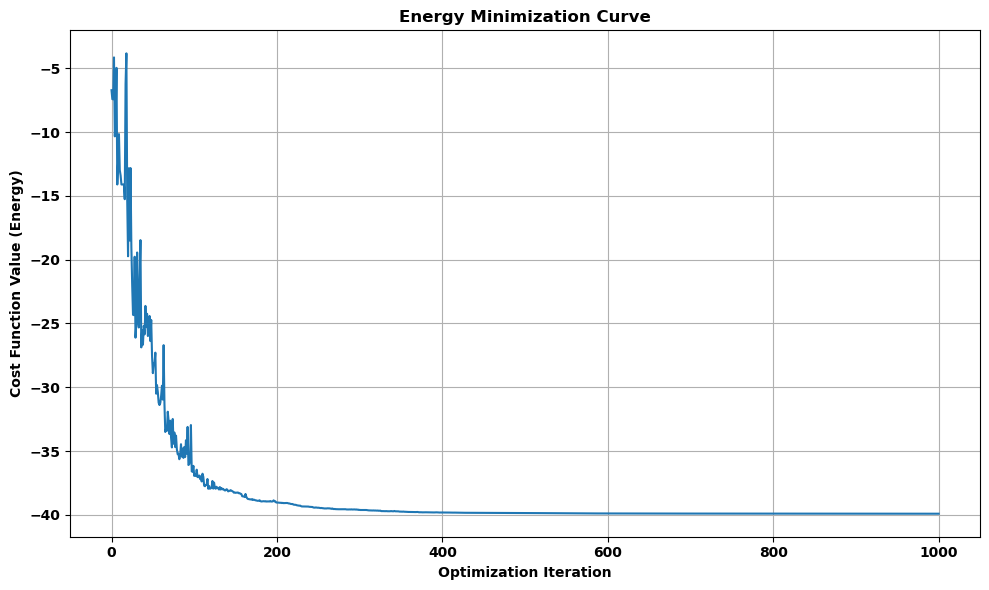

The counts are: {'0110': 1024}


C:\Users\ssromerogon\Documents\vscode_working_dir\QuantumXCT\python\cc_grn_functions\quantum_functions.py:395: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  plot_histogram(counts, bar_labels=True, title=title).show()


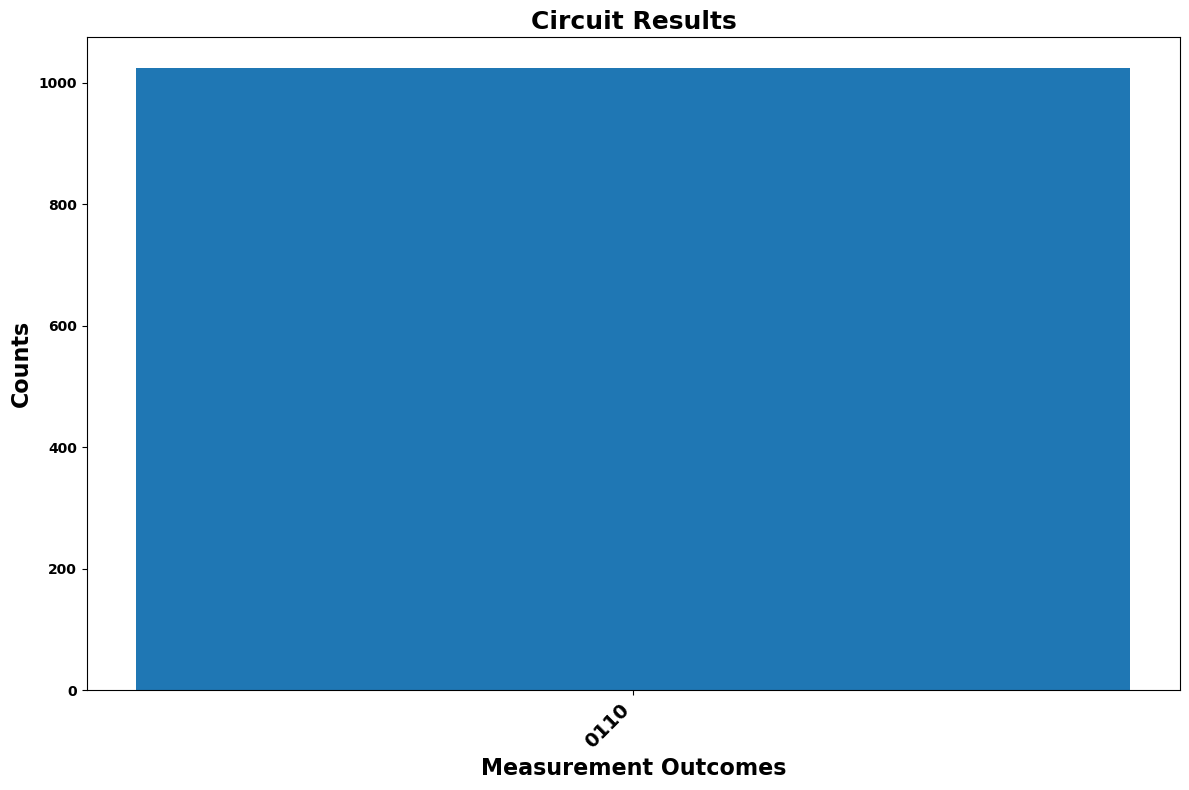

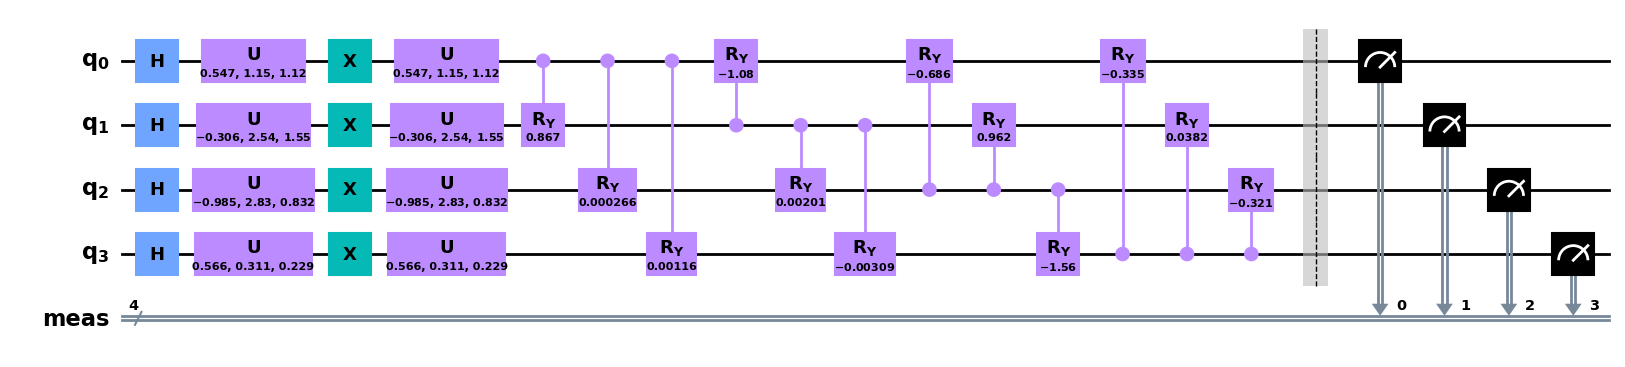

In [20]:
min_ones = 0

result_interaction_bfgs, optimized_full_params_ct1_mo, cost_values = vqe_solver(
    joint_counts_ct1_mo,
    ansatz_grn_ct1_mo, # Renamed from 'cirquit' for common convention
    ct1_percentages_mo, # Renamed from 'act_percentages' for consistency with create_parameter_dictionaries_cust
    cost_func_wrapper, # This function needs to be defined to accept the correct arguments (see comments below)
    min_ones_obs=min_ones, # Added as an explicit argument for flexibility
    optimizer_method="COBYLA",# COBYLA | L-BFGS-B
)

# Plot the cost function values
plt.figure(figsize=(10, 6))
plt.plot(cost_values)
plt.xlabel("Optimization Iteration")
plt.ylabel("Cost Function Value (Energy)")
plt.title("Energy Minimization Curve")
plt.grid(True)
plt.tight_layout()
plt.show()
counts, bound_circuit = evaluate_and_plot_ansatz(ansatz_grn_ct1_mo, optimized_full_params_ct1_mo, shots=1024, title="Circuit Results")
bound_circuit.draw(output="mpl", style="clifford", fold=40)  # Show the circuit plot

Interaction observable CT from histogram: SparsePauliOp(['III', 'IIZ', 'IZI', 'IZZ', 'ZII', 'ZIZ', 'ZZI', 'ZZZ'],
              coeffs=[-10.        +0.j,  -2.04682779+0.j,  14.75453172+0.j,  -3.19864048+0.j,
  -2.00151057+0.j,  -1.05740181+0.j,   1.86933535+0.j,   0.92522659+0.j])
Static Parameters: {Parameter(ct2_act_0): 1.319279090178191, Parameter(ct2_act_1): 3.1107462000424615, Parameter(ct2_act_2): 1.627743625651509}
Variable Parameters: {Parameter(ct2_grn_0_1): 0.0, Parameter(ct2_grn_0_2): 0.0, Parameter(ct2_grn_1_0): 0.0, Parameter(ct2_grn_1_2): 0.0, Parameter(ct2_grn_2_0): 0.0, Parameter(ct2_grn_2_1): 0.0, Parameter(ct2_post_acti2_0): 0.0, Parameter(ct2_post_acti2_1): 0.0, Parameter(ct2_post_acti2_2): 0.0, Parameter(ct2_post_acti_0): 0.0, Parameter(ct2_post_acti_1): 0.0, Parameter(ct2_post_acti_2): 0.0}
Starting optimization with method: COBYLA
Iteration 0: Current cost: -17.55353674806785
Iteration 20: Current cost: -17.346604917537462
Iteration 40: Current cost: -24.438733288

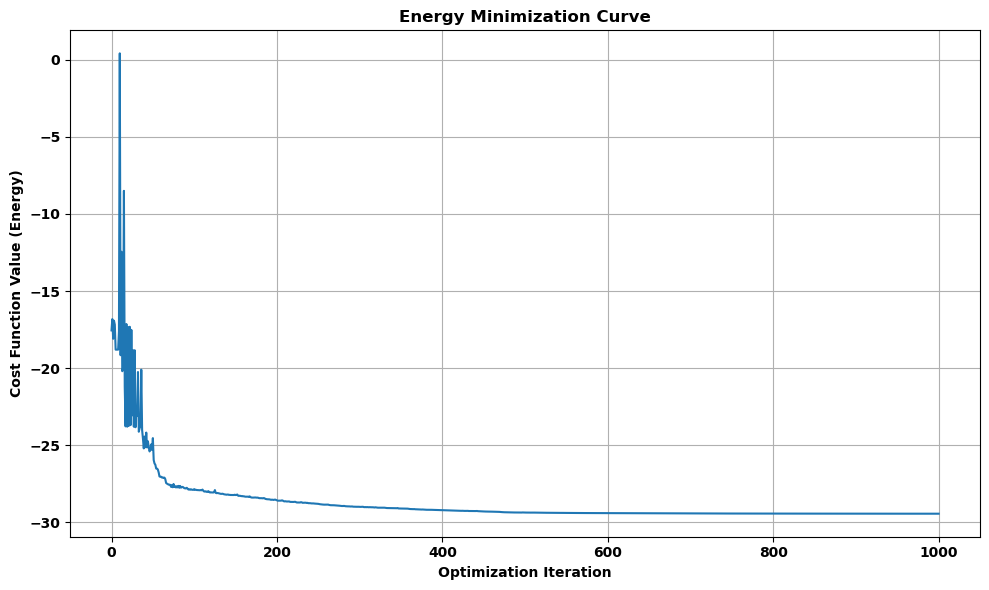

The counts are: {'010': 1017, '011': 7}


C:\Users\ssromerogon\Documents\vscode_working_dir\QuantumXCT\python\cc_grn_functions\quantum_functions.py:395: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  plot_histogram(counts, bar_labels=True, title=title).show()


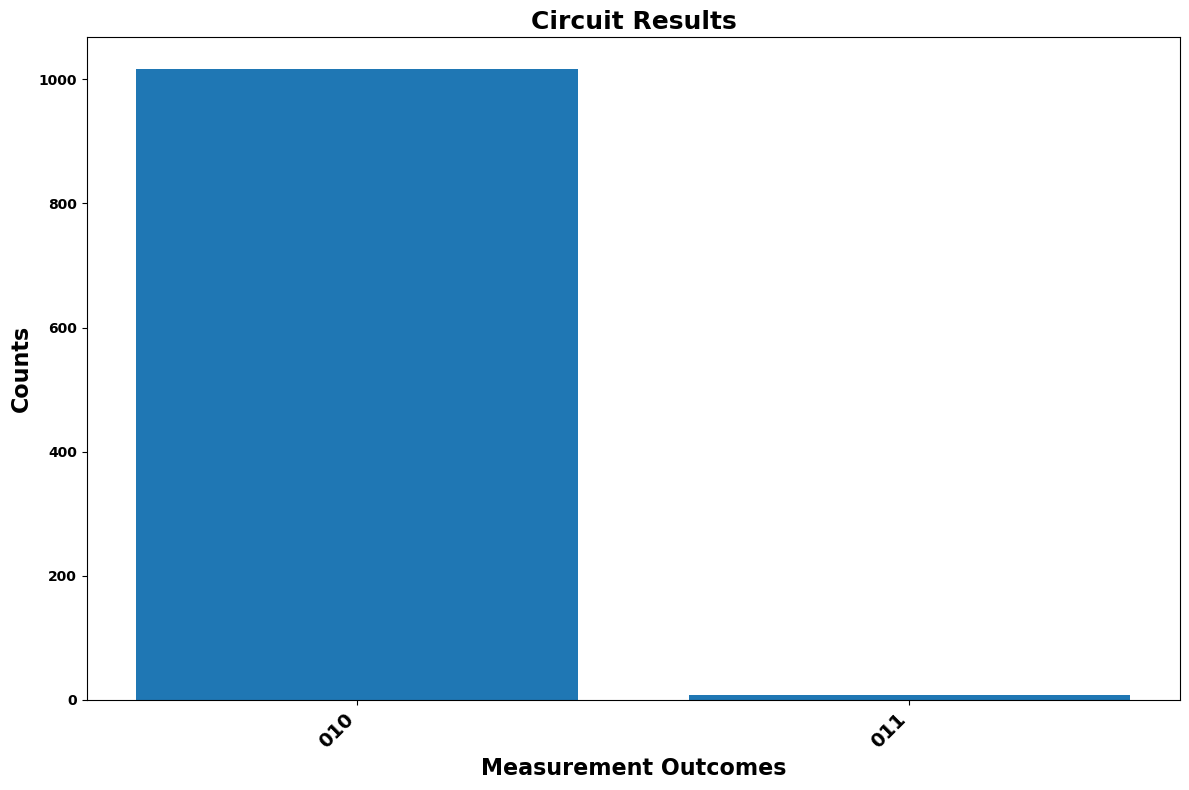

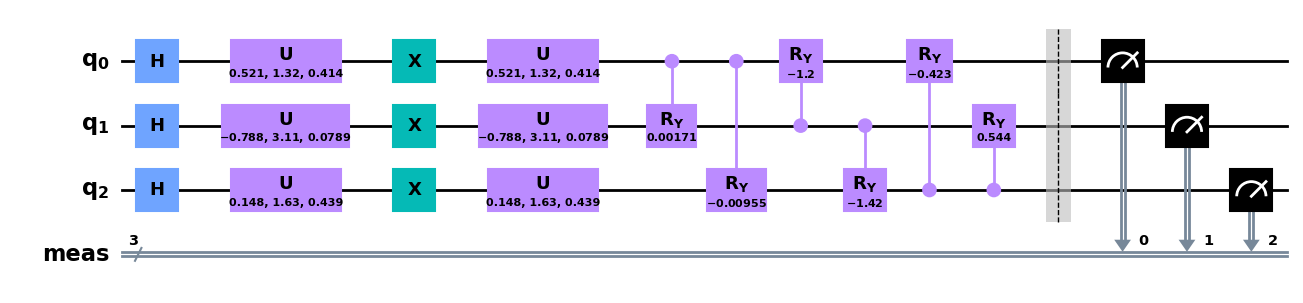

In [21]:
min_ones = 0

result_interaction_bfgs, optimized_full_params_ct2_co, cost_values = vqe_solver(
    joint_counts_ct2_co,
    ansatz_grn_ct2_co, # Renamed from 'cirquit' for common convention
    ct2_percentages_co, # Renamed from 'act_percentages' for consistency with create_parameter_dictionaries_cust
    cost_func_wrapper, # This function needs to be defined to accept the correct arguments (see comments below)
    min_ones_obs=min_ones, # Added as an explicit argument for flexibility
    optimizer_method="COBYLA",# COBYLA | L-BFGS-B
)

# Plot the cost function values
plt.figure(figsize=(10, 6))
plt.plot(cost_values)
plt.xlabel("Optimization Iteration")
plt.ylabel("Cost Function Value (Energy)")
plt.title("Energy Minimization Curve")
plt.grid(True)
plt.tight_layout()
plt.show()
counts, bound_circuit = evaluate_and_plot_ansatz(ansatz_grn_ct2_co, optimized_full_params_ct2_co, shots=1024, title="Circuit Results")
bound_circuit.draw(output="mpl", style="clifford", fold=40)  # Show the circuit plot

Interaction observable CT from histogram: SparsePauliOp(['III', 'IIZ', 'IZI', 'IZZ', 'ZII', 'ZIZ', 'ZZI', 'ZZZ'],
              coeffs=[-12.5       +0.j,  -1.75753228+0.j,  12.03371593+0.j,   1.54232425+0.j,
  -5.20086083+0.j,  -1.41678623+0.j,   4.91391679+0.j,   1.34505022+0.j])
Static Parameters: {Parameter(ct2_act_0): 0.9172368794914246, Parameter(ct2_act_1): 3.0829976686591367, Parameter(ct2_act_2): 1.3499383066716542}
Variable Parameters: {Parameter(ct2_grn_0_1): 0.0, Parameter(ct2_grn_0_2): 0.0, Parameter(ct2_grn_1_0): 0.0, Parameter(ct2_grn_1_2): 0.0, Parameter(ct2_grn_2_0): 0.0, Parameter(ct2_grn_2_1): 0.0, Parameter(ct2_post_acti2_0): 0.0, Parameter(ct2_post_acti2_1): 0.0, Parameter(ct2_post_acti2_2): 0.0, Parameter(ct2_post_acti_0): 0.0, Parameter(ct2_post_acti_1): 0.0, Parameter(ct2_post_acti_2): 0.0}
Starting optimization with method: COBYLA
Iteration 0: Current cost: -16.914100843907978
Iteration 20: Current cost: -25.635694582243104
Iteration 40: Current cost: -33.052543

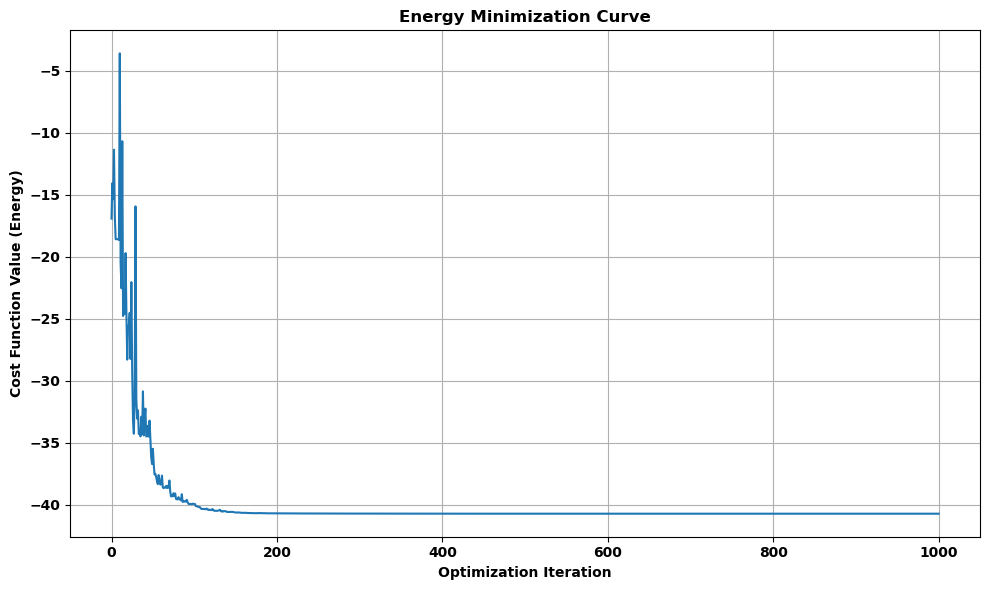

The counts are: {'010': 1024}


C:\Users\ssromerogon\Documents\vscode_working_dir\QuantumXCT\python\cc_grn_functions\quantum_functions.py:395: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  plot_histogram(counts, bar_labels=True, title=title).show()


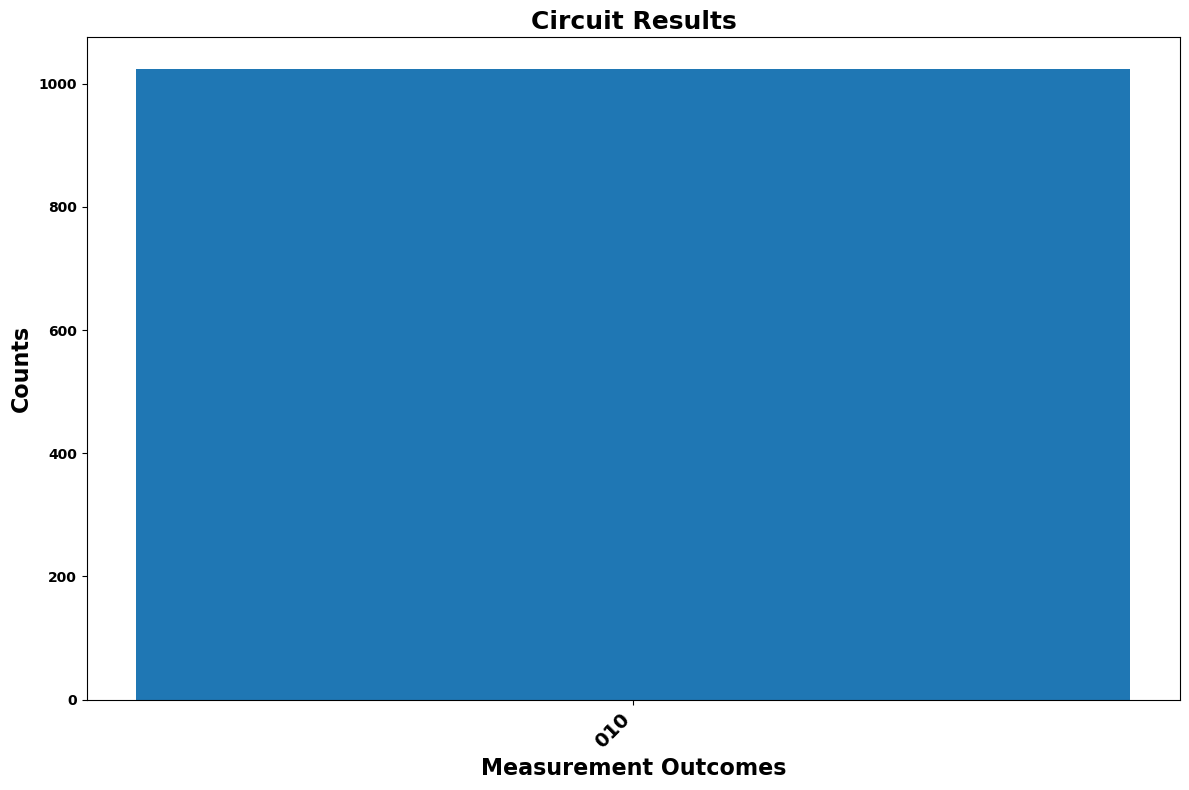

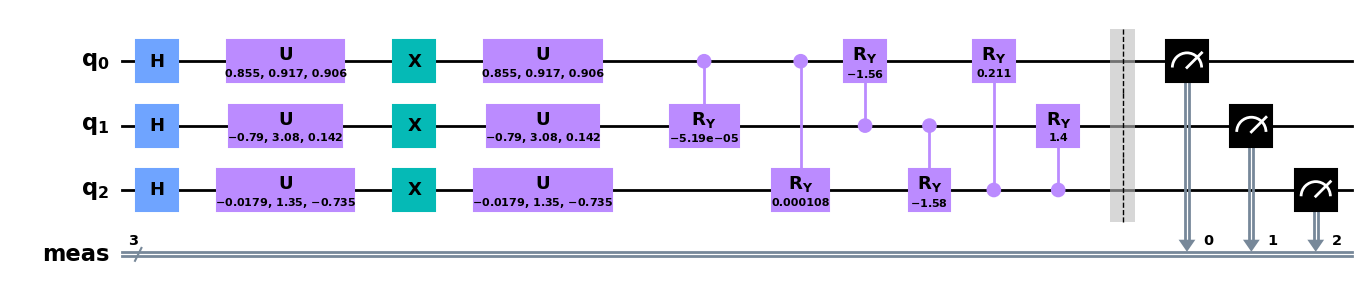

In [22]:
min_ones = 0

result_interaction_bfgs, optimized_full_params_ct2_mo, cost_values = vqe_solver(
    joint_counts_ct2_mo,
    ansatz_grn_ct2_mo, # Renamed from 'cirquit' for common convention
    ct2_percentages_mo, # Renamed from 'act_percentages' for consistency with create_parameter_dictionaries_cust
    cost_func_wrapper, # This function needs to be defined to accept the correct arguments (see comments below)
    min_ones_obs=min_ones, # Added as an explicit argument for flexibility
    optimizer_method="COBYLA",# COBYLA | L-BFGS-B
)

# Plot the cost function values
plt.figure(figsize=(10, 6))
plt.plot(cost_values)
plt.xlabel("Optimization Iteration")
plt.ylabel("Cost Function Value (Energy)")
plt.title("Energy Minimization Curve")
plt.grid(True)
plt.tight_layout()
plt.show()
counts, bound_circuit = evaluate_and_plot_ansatz(ansatz_grn_ct2_mo, optimized_full_params_ct2_mo, shots=1024, title="Circuit Results")
bound_circuit.draw(output="mpl", style="clifford", fold=40)  # Show the circuit plot

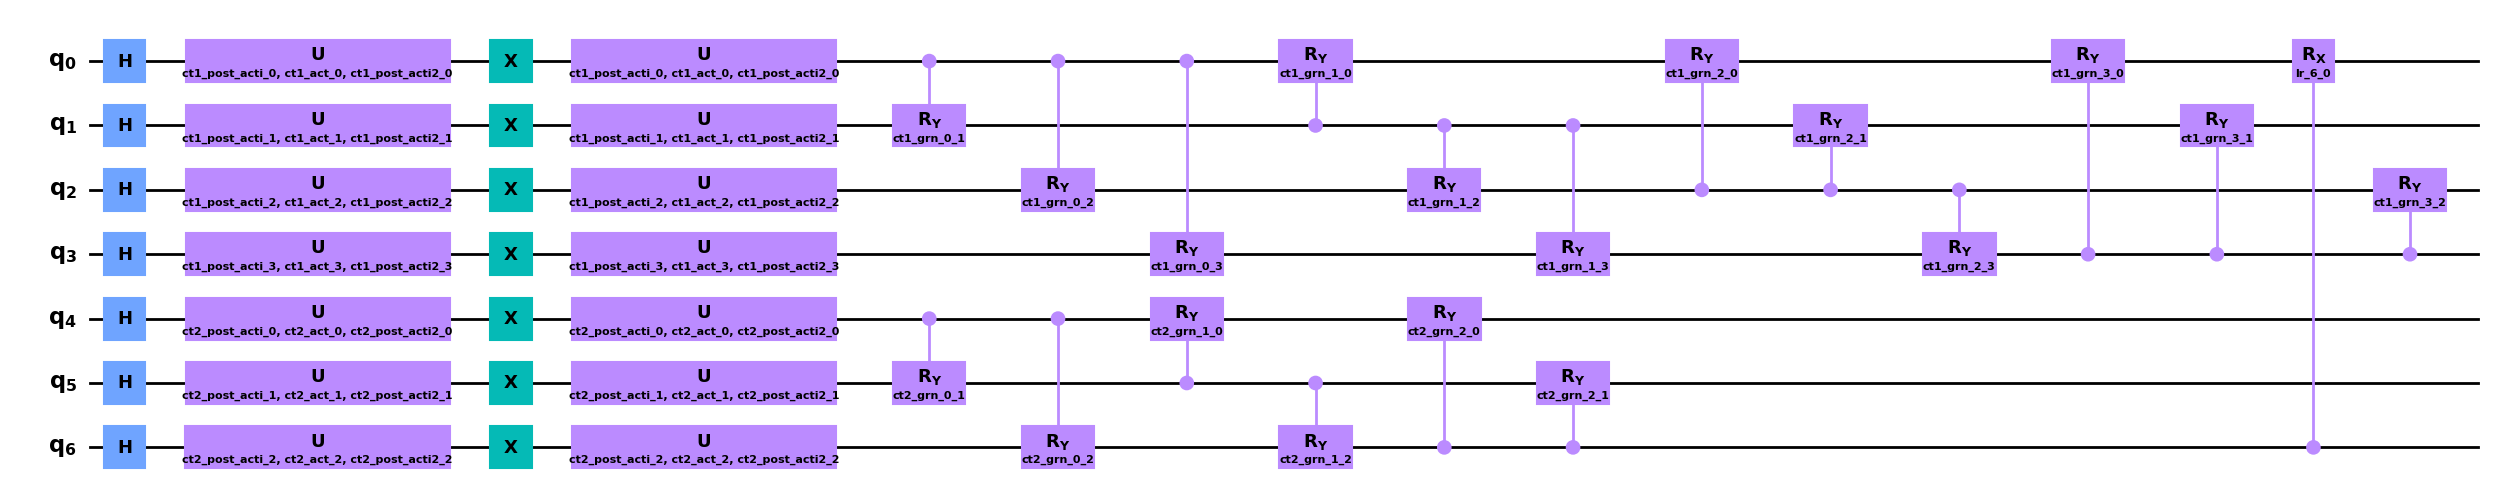

In [23]:
interactions_lr = {
    (ng_ct1 + ng_ct2 - 1, 0): 10,
}
cc_grn_circuit_co = create_joint_circuit_from_ansatzes(ansatz_grn_ct1_co, ansatz_grn_ct2_co, interactions = interactions_lr)
cc_grn_circuit_mo = create_joint_circuit_from_ansatzes(ansatz_grn_ct1_mo, ansatz_grn_ct2_mo, interactions = interactions_lr)
cc_grn_circuit_mo.draw(output="mpl", style="clifford", fold=40)  # Show the circuit plot

--- Starting VQE LR Solver ---
Initial combined parameters for LR optimization: {Parameter(ct1_act_0): 1.1775418008504883, Parameter(ct1_act_1): 2.51060799049255, Parameter(ct1_act_2): 2.7727776744554893, Parameter(ct1_act_3): 0.9398116636976538, Parameter(ct1_grn_0_1): 0.7580049769192613, Parameter(ct1_grn_0_2): -0.02335491760542047, Parameter(ct1_grn_0_3): 0.003616930331863851, Parameter(ct1_grn_1_0): -1.6738784666275481, Parameter(ct1_grn_1_2): 0.5245605895745701, Parameter(ct1_grn_1_3): -0.17554242899746386, Parameter(ct1_grn_2_0): -0.07146259739716819, Parameter(ct1_grn_2_1): 0.49811206959128995, Parameter(ct1_grn_2_3): -1.3722582237172767, Parameter(ct1_grn_3_0): 0.4264385114076354, Parameter(ct1_grn_3_1): 1.0600857719118404, Parameter(ct1_grn_3_2): -0.17309887244356467, Parameter(ct1_post_acti2_0): 0.18902283290718294, Parameter(ct1_post_acti2_1): 0.5396404456793604, Parameter(ct1_post_acti2_2): 0.12513152074129297, Parameter(ct1_post_acti2_3): 0.8578653632587603, Parameter(ct1_

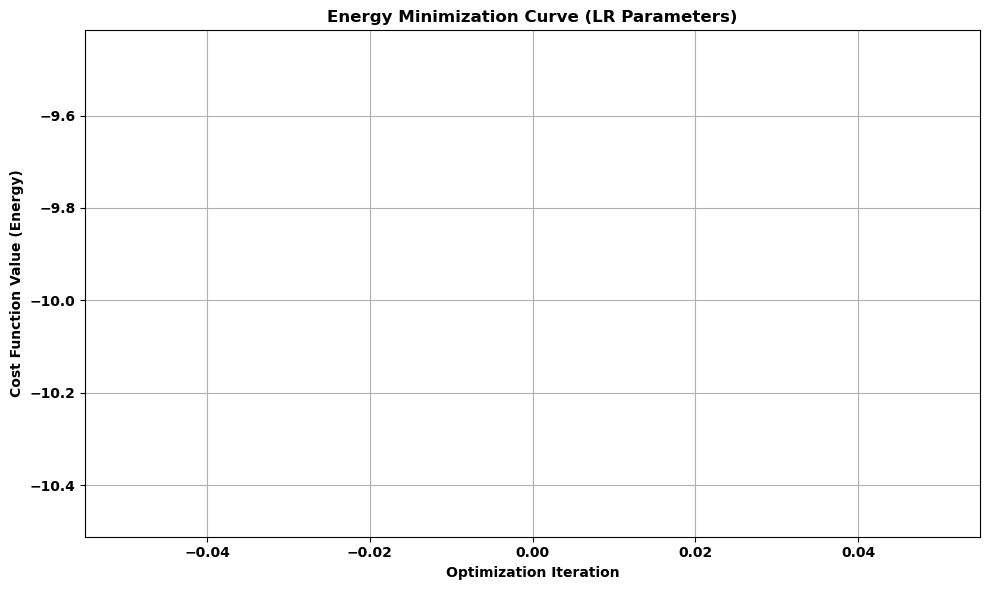

The counts are: {'0100110': 1006, '0100000': 3, '0101000': 6, '0100010': 4, '0101010': 1, '0100101': 1, '0100111': 1, '0110110': 2}


C:\Users\ssromerogon\Documents\vscode_working_dir\QuantumXCT\python\cc_grn_functions\quantum_functions.py:395: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  plot_histogram(counts, bar_labels=True, title=title).show()


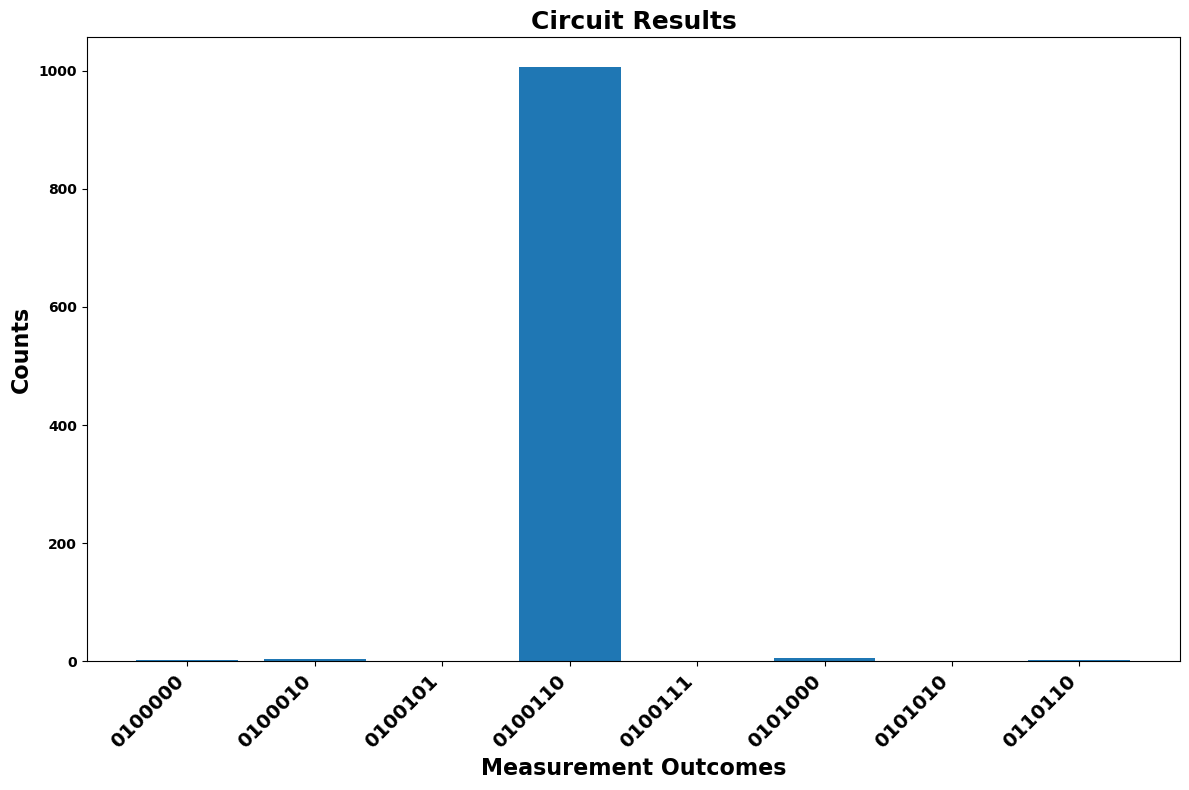

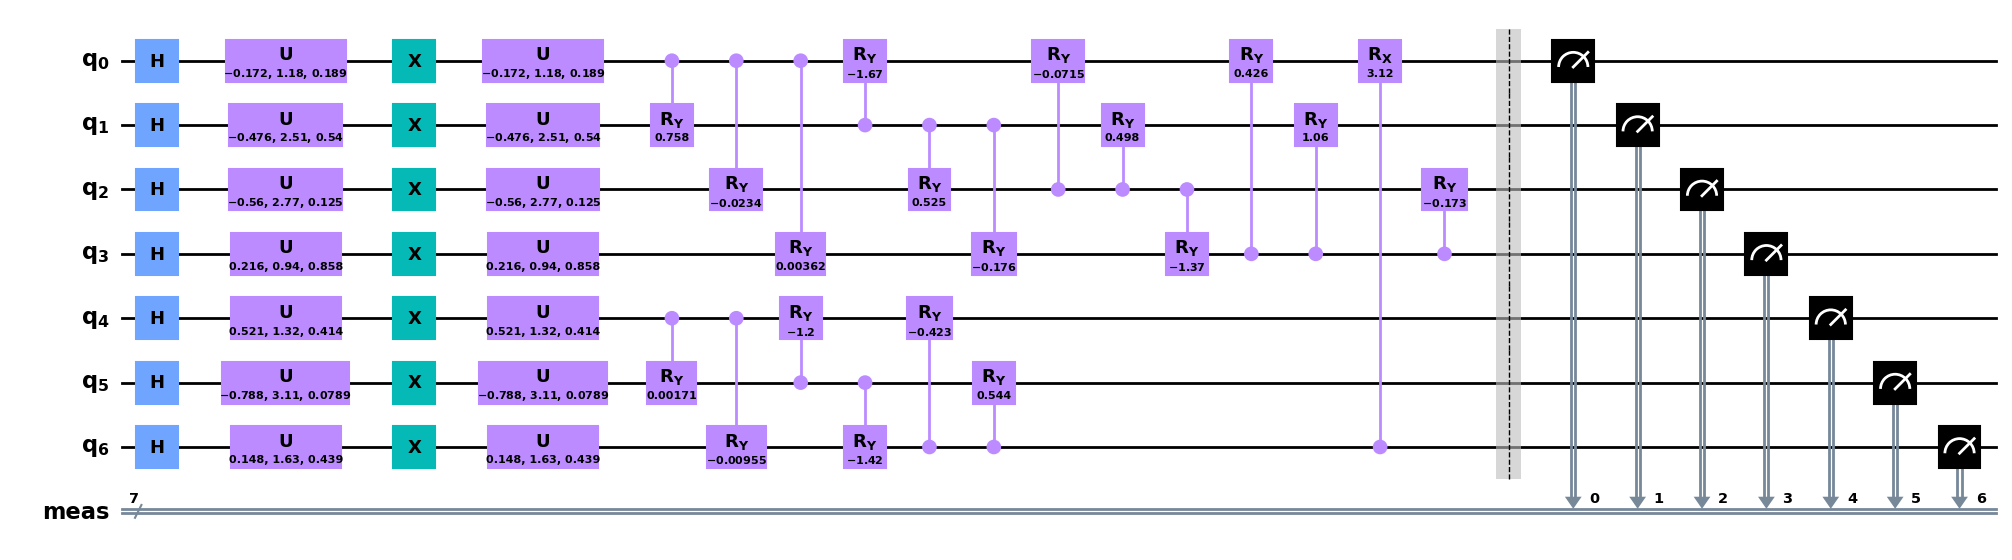

In [24]:
# --- Calling the vqe_lr_solver function with your variables ---
print("--- Starting VQE LR Solver ---")
result_lr_bfgs, optimized_full_params_lr_co, cost_values_from_solver = vqe_lr_solver(
    cc_grn_circuit_co,
    optimized_full_params_ct1_co,
    optimized_full_params_ct2_co,
    interactions_lr,
    ansatz_grn_ct1_co.num_qubits,
    ansatz_grn_ct2_co.num_qubits,
    cost_func_wrapper,
    create_parameter_dictionaries_from_circuit,
    create_interaction_observable_general
)

print("\n--- VQE LR Solver Completed ---")
print("Final optimized parameters:", optimized_full_params_lr_co)

# --- Plotting the cost values ---
plt.figure(figsize=(10, 6))
plt.plot(cost_values_from_solver)
plt.xlabel("Optimization Iteration")
plt.ylabel("Cost Function Value (Energy)")
plt.title("Energy Minimization Curve (LR Parameters)")
plt.grid(True)
plt.tight_layout()
plt.show()
counts_cc_grn_co, bound_circuit = evaluate_and_plot_ansatz(cc_grn_circuit_co, optimized_full_params_lr_co, shots=1024, title="Circuit Results")
bound_circuit.draw(output="mpl", style="clifford", fold=40)  # Show the circuit plot

--- Starting VQE LR Solver ---
Initial combined parameters for LR optimization: {Parameter(ct1_act_0): 1.1548409543018316, Parameter(ct1_act_1): 2.5356001620344015, Parameter(ct1_act_2): 2.8253070987867597, Parameter(ct1_act_3): 0.31096983119289834, Parameter(ct1_grn_0_1): 0.8669889858973558, Parameter(ct1_grn_0_2): 0.0002656481975044512, Parameter(ct1_grn_0_3): 0.0011603124793151559, Parameter(ct1_grn_1_0): -1.0757284167780485, Parameter(ct1_grn_1_2): 0.0020111476660232695, Parameter(ct1_grn_1_3): -0.0030902742262312534, Parameter(ct1_grn_2_0): -0.6857436585555006, Parameter(ct1_grn_2_1): 0.9615561990149669, Parameter(ct1_grn_2_3): -1.5583283686579803, Parameter(ct1_grn_3_0): -0.3350362725954602, Parameter(ct1_grn_3_1): 0.038222359076715, Parameter(ct1_grn_3_2): -0.32077903031195437, Parameter(ct1_post_acti2_0): 1.1212897140128562, Parameter(ct1_post_acti2_1): 1.5522032439862388, Parameter(ct1_post_acti2_2): 0.8317061057835756, Parameter(ct1_post_acti2_3): 0.22868280529444268, Paramet

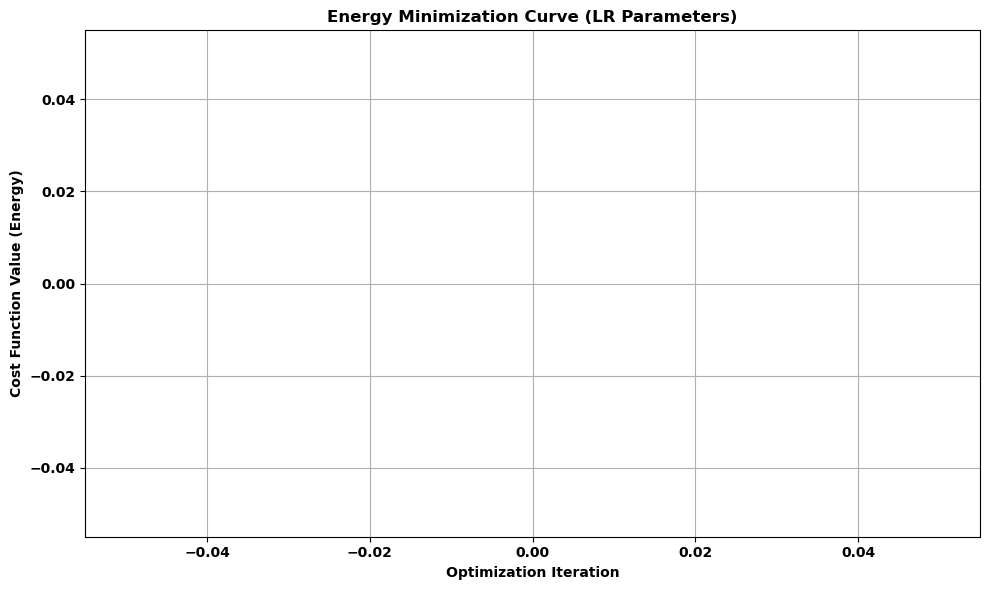

The counts are: {'0100110': 1024}


C:\Users\ssromerogon\Documents\vscode_working_dir\QuantumXCT\python\cc_grn_functions\quantum_functions.py:395: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  plot_histogram(counts, bar_labels=True, title=title).show()


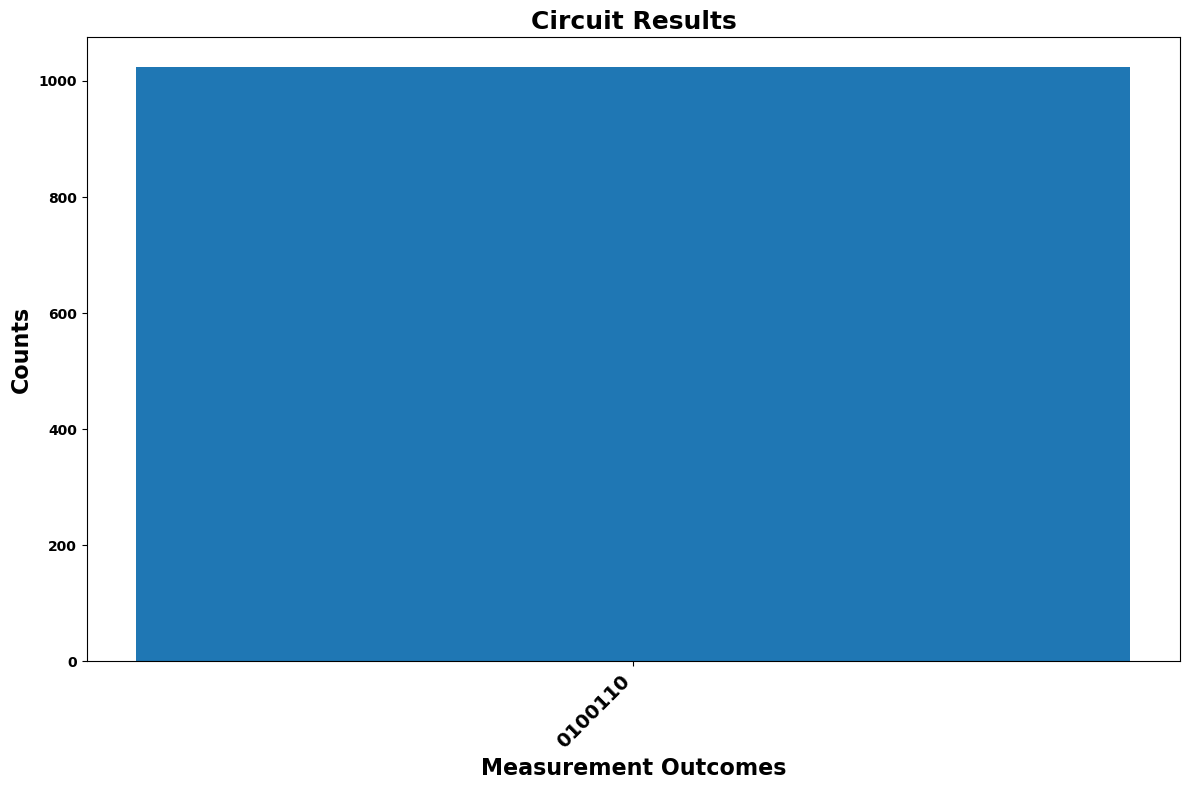

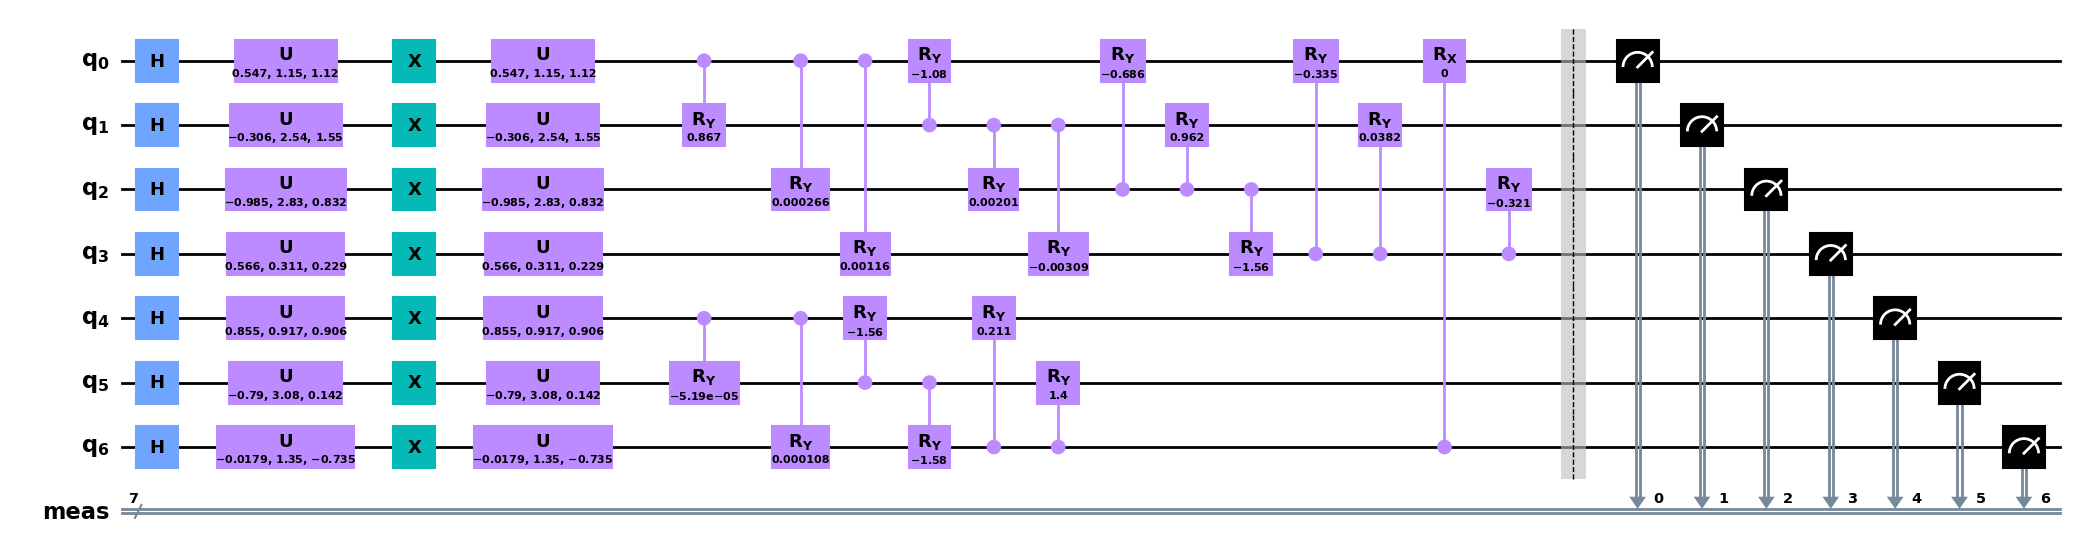

In [25]:
# --- Calling the vqe_lr_solver function with your variables ---
print("--- Starting VQE LR Solver ---")
result_lr_bfgs, optimized_full_params_lr_mo, cost_values_from_solver = vqe_lr_solver(
    cc_grn_circuit_mo,
    optimized_full_params_ct1_mo,
    optimized_full_params_ct2_mo,
    interactions_lr,
    ansatz_grn_ct1_mo.num_qubits,
    ansatz_grn_ct2_mo.num_qubits,
    cost_func_wrapper,
    create_parameter_dictionaries_from_circuit,
    create_interaction_observable_general
)

print("\n--- VQE LR Solver Completed ---")
print("Final optimized parameters:", optimized_full_params_lr_mo)

# --- Plotting the cost values ---
plt.figure(figsize=(10, 6))
plt.plot(cost_values_from_solver)
plt.xlabel("Optimization Iteration")
plt.ylabel("Cost Function Value (Energy)")
plt.title("Energy Minimization Curve (LR Parameters)")
plt.grid(True)
plt.tight_layout()
plt.show()
counts_cc_grn_mo, bound_circuit = evaluate_and_plot_ansatz(cc_grn_circuit_mo, optimized_full_params_lr_mo, shots=1024, title="Circuit Results")
bound_circuit.draw(output="mpl", style="clifford", fold=40)  # Show the circuit plot

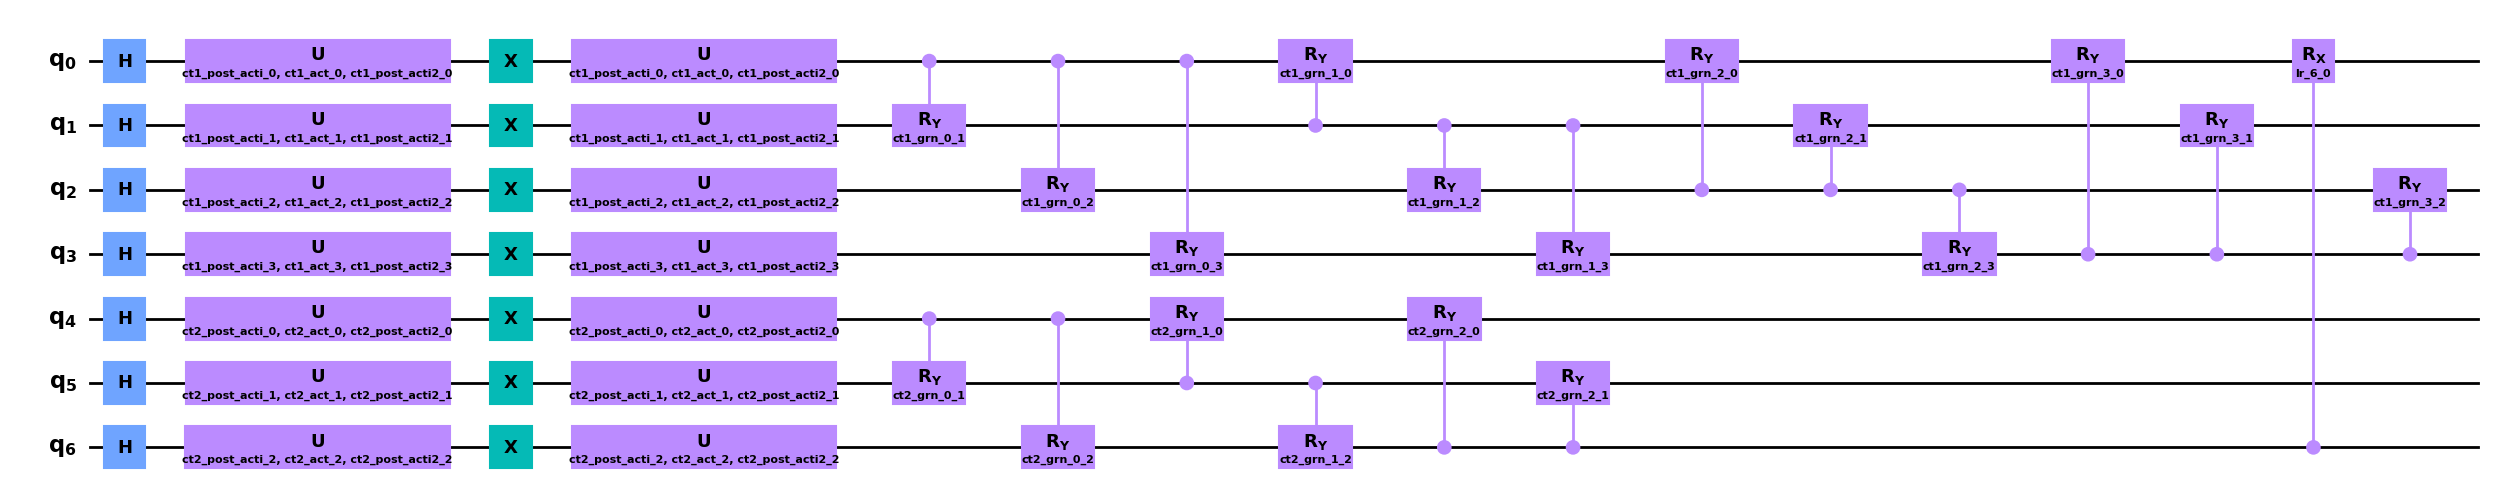

In [26]:
interactions_lr = {
    (ng_ct1 + ng_ct2 - 1, 0): 0,
}
cc_grn_circuit_co0 = create_joint_circuit_from_ansatzes(ansatz_grn_ct1_co, ansatz_grn_ct2_co, interactions = interactions_lr)
cc_grn_circuit_mo0 = create_joint_circuit_from_ansatzes(ansatz_grn_ct1_mo, ansatz_grn_ct2_mo, interactions = interactions_lr)
cc_grn_circuit_mo0.draw(output="mpl", style="clifford", fold=40)  # Show the circuit plot

--- Starting VQE LR Solver ---
Initial combined parameters for LR optimization: {Parameter(ct1_act_0): 1.1775418008504883, Parameter(ct1_act_1): 2.51060799049255, Parameter(ct1_act_2): 2.7727776744554893, Parameter(ct1_act_3): 0.9398116636976538, Parameter(ct1_grn_0_1): 0.7580049769192613, Parameter(ct1_grn_0_2): -0.02335491760542047, Parameter(ct1_grn_0_3): 0.003616930331863851, Parameter(ct1_grn_1_0): -1.6738784666275481, Parameter(ct1_grn_1_2): 0.5245605895745701, Parameter(ct1_grn_1_3): -0.17554242899746386, Parameter(ct1_grn_2_0): -0.07146259739716819, Parameter(ct1_grn_2_1): 0.49811206959128995, Parameter(ct1_grn_2_3): -1.3722582237172767, Parameter(ct1_grn_3_0): 0.4264385114076354, Parameter(ct1_grn_3_1): 1.0600857719118404, Parameter(ct1_grn_3_2): -0.17309887244356467, Parameter(ct1_post_acti2_0): 0.18902283290718294, Parameter(ct1_post_acti2_1): 0.5396404456793604, Parameter(ct1_post_acti2_2): 0.12513152074129297, Parameter(ct1_post_acti2_3): 0.8578653632587603, Parameter(ct1_

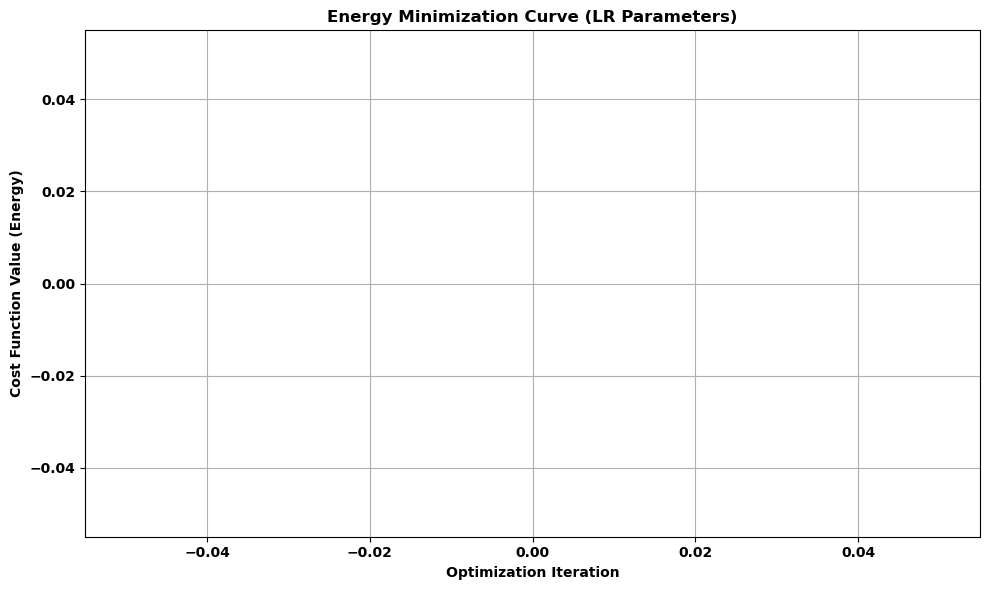

The counts are: {'0100110': 1013, '0100000': 3, '0110110': 5, '0101000': 1, '0100100': 2}


C:\Users\ssromerogon\Documents\vscode_working_dir\QuantumXCT\python\cc_grn_functions\quantum_functions.py:395: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  plot_histogram(counts, bar_labels=True, title=title).show()


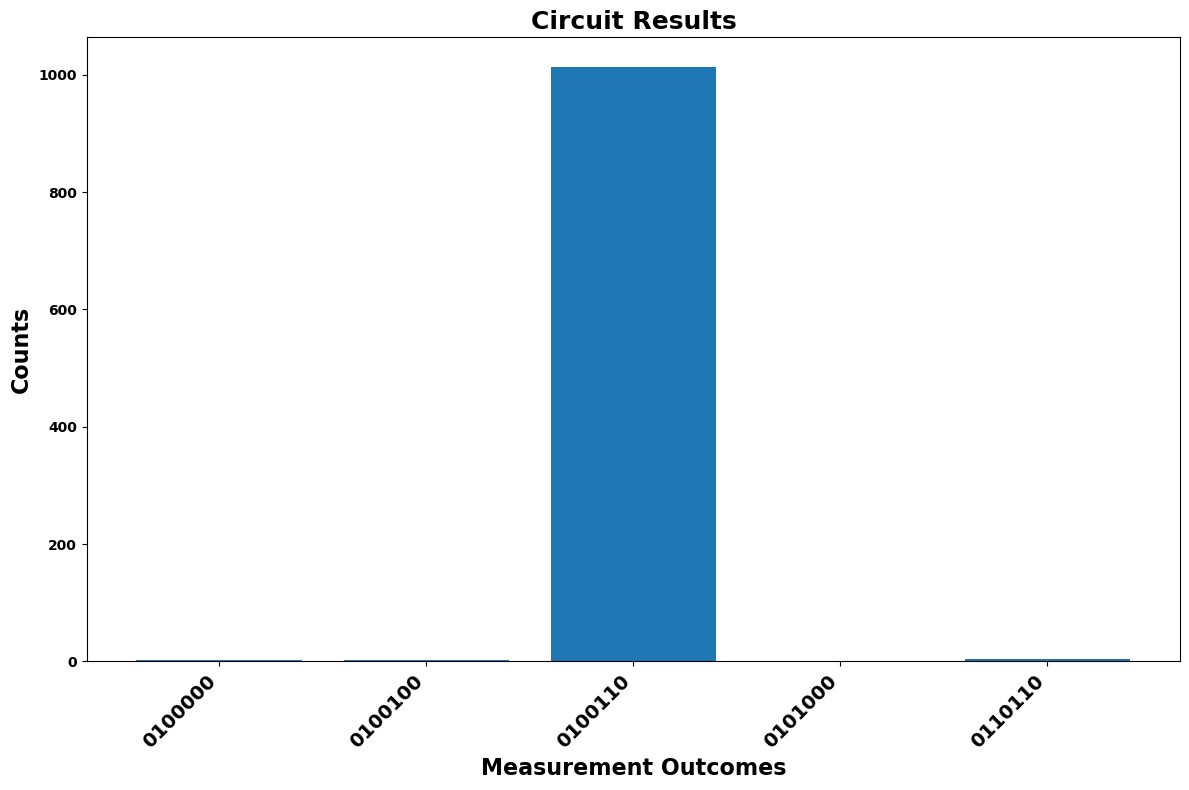

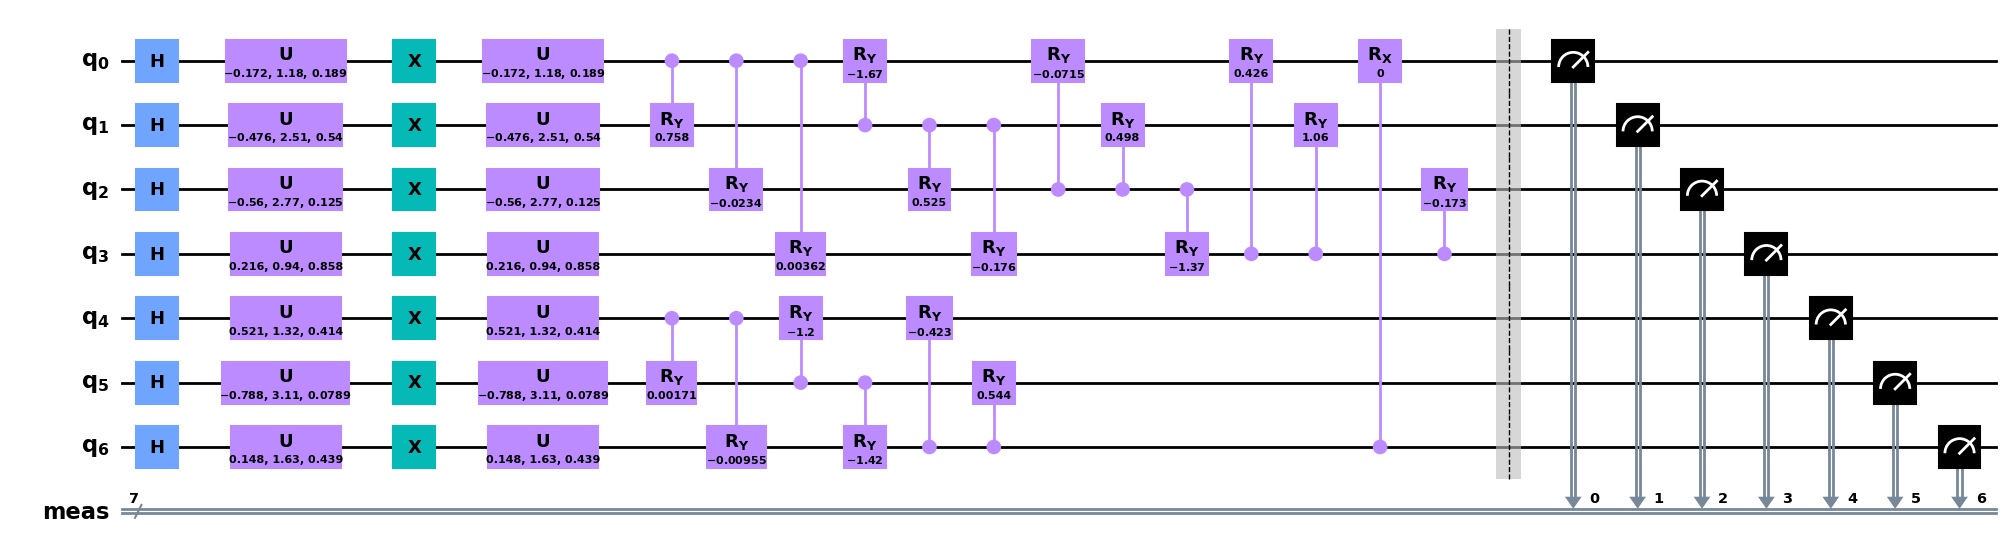

In [27]:
# --- Calling the vqe_lr_solver function with your variables ---
print("--- Starting VQE LR Solver ---")
result_lr_bfgs, optimized_full_params_lr_co0, cost_values_from_solver = vqe_lr_solver(
    cc_grn_circuit_co0,
    optimized_full_params_ct1_co,
    optimized_full_params_ct2_co,
    interactions_lr,
    ansatz_grn_ct1_co.num_qubits,
    ansatz_grn_ct2_co.num_qubits,
    cost_func_wrapper,
    create_parameter_dictionaries_from_circuit,
    create_interaction_observable_general
)

print("\n--- VQE LR Solver Completed ---")
print("Final optimized parameters:", optimized_full_params_lr_co0)

# --- Plotting the cost values ---
plt.figure(figsize=(10, 6))
plt.plot(cost_values_from_solver)
plt.xlabel("Optimization Iteration")
plt.ylabel("Cost Function Value (Energy)")
plt.title("Energy Minimization Curve (LR Parameters)")
plt.grid(True)
plt.tight_layout()
plt.show()
counts_cc_grn_co0, bound_circuit = evaluate_and_plot_ansatz(cc_grn_circuit_co0, optimized_full_params_lr_co0, shots=1024, title="Circuit Results")
bound_circuit.draw(output="mpl", style="clifford", fold=40)  # Show the circuit plot

--- Starting VQE LR Solver ---
Initial combined parameters for LR optimization: {Parameter(ct1_act_0): 1.1548409543018316, Parameter(ct1_act_1): 2.5356001620344015, Parameter(ct1_act_2): 2.8253070987867597, Parameter(ct1_act_3): 0.31096983119289834, Parameter(ct1_grn_0_1): 0.8669889858973558, Parameter(ct1_grn_0_2): 0.0002656481975044512, Parameter(ct1_grn_0_3): 0.0011603124793151559, Parameter(ct1_grn_1_0): -1.0757284167780485, Parameter(ct1_grn_1_2): 0.0020111476660232695, Parameter(ct1_grn_1_3): -0.0030902742262312534, Parameter(ct1_grn_2_0): -0.6857436585555006, Parameter(ct1_grn_2_1): 0.9615561990149669, Parameter(ct1_grn_2_3): -1.5583283686579803, Parameter(ct1_grn_3_0): -0.3350362725954602, Parameter(ct1_grn_3_1): 0.038222359076715, Parameter(ct1_grn_3_2): -0.32077903031195437, Parameter(ct1_post_acti2_0): 1.1212897140128562, Parameter(ct1_post_acti2_1): 1.5522032439862388, Parameter(ct1_post_acti2_2): 0.8317061057835756, Parameter(ct1_post_acti2_3): 0.22868280529444268, Paramet

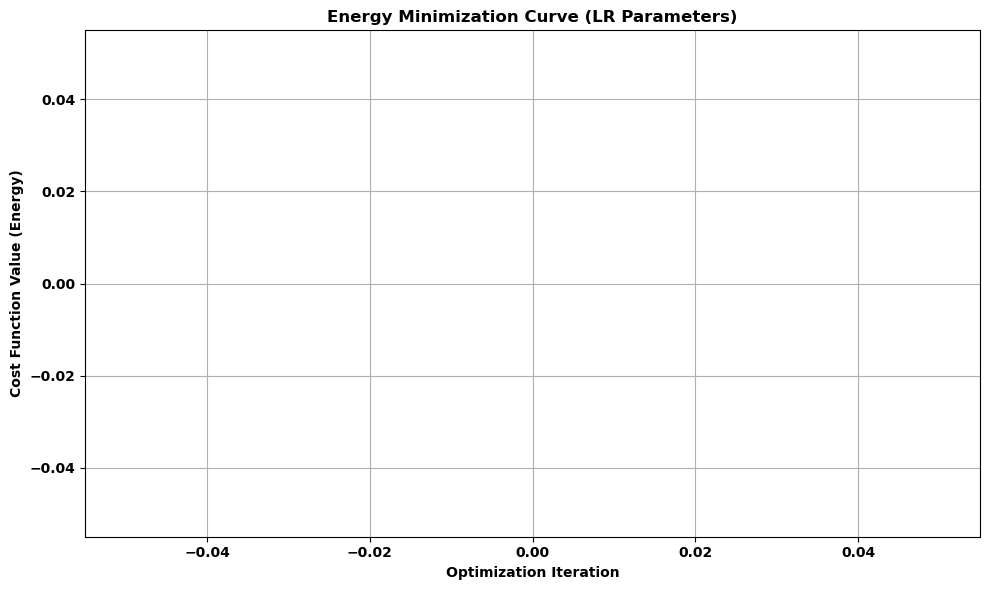

The counts are: {'0100110': 1024}


C:\Users\ssromerogon\Documents\vscode_working_dir\QuantumXCT\python\cc_grn_functions\quantum_functions.py:395: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  plot_histogram(counts, bar_labels=True, title=title).show()


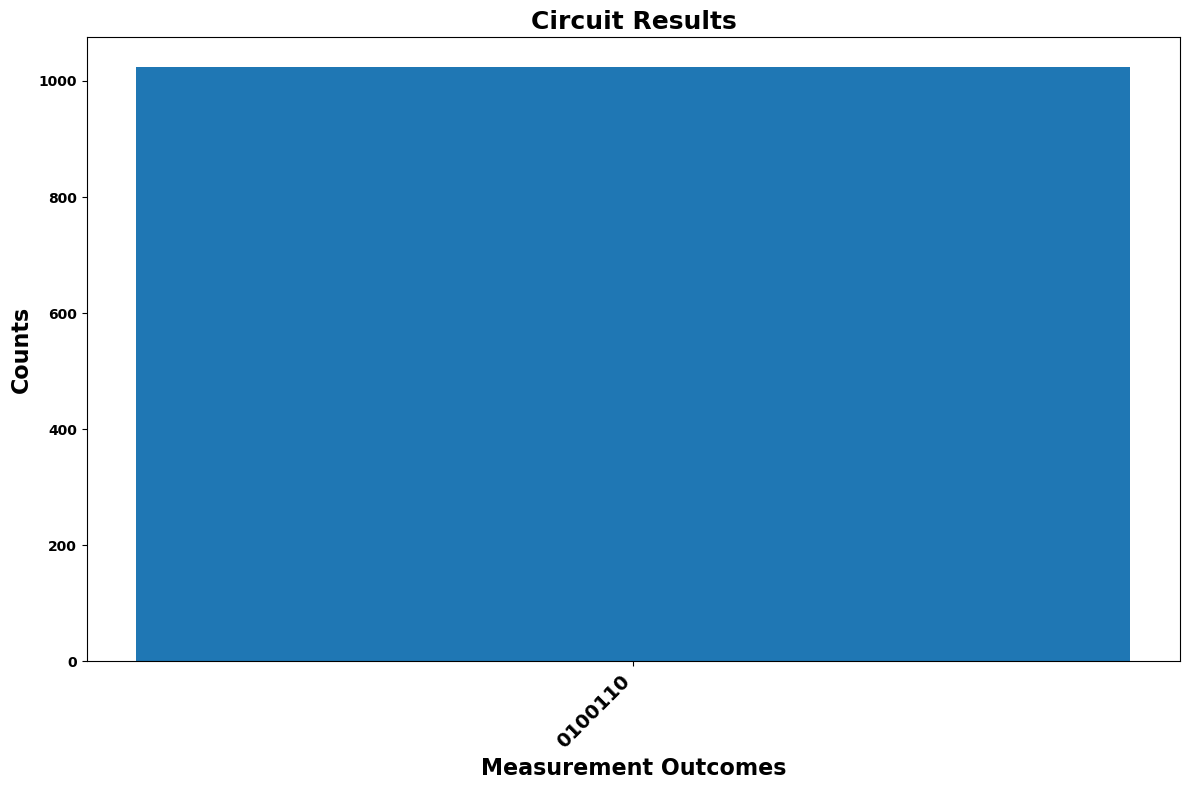

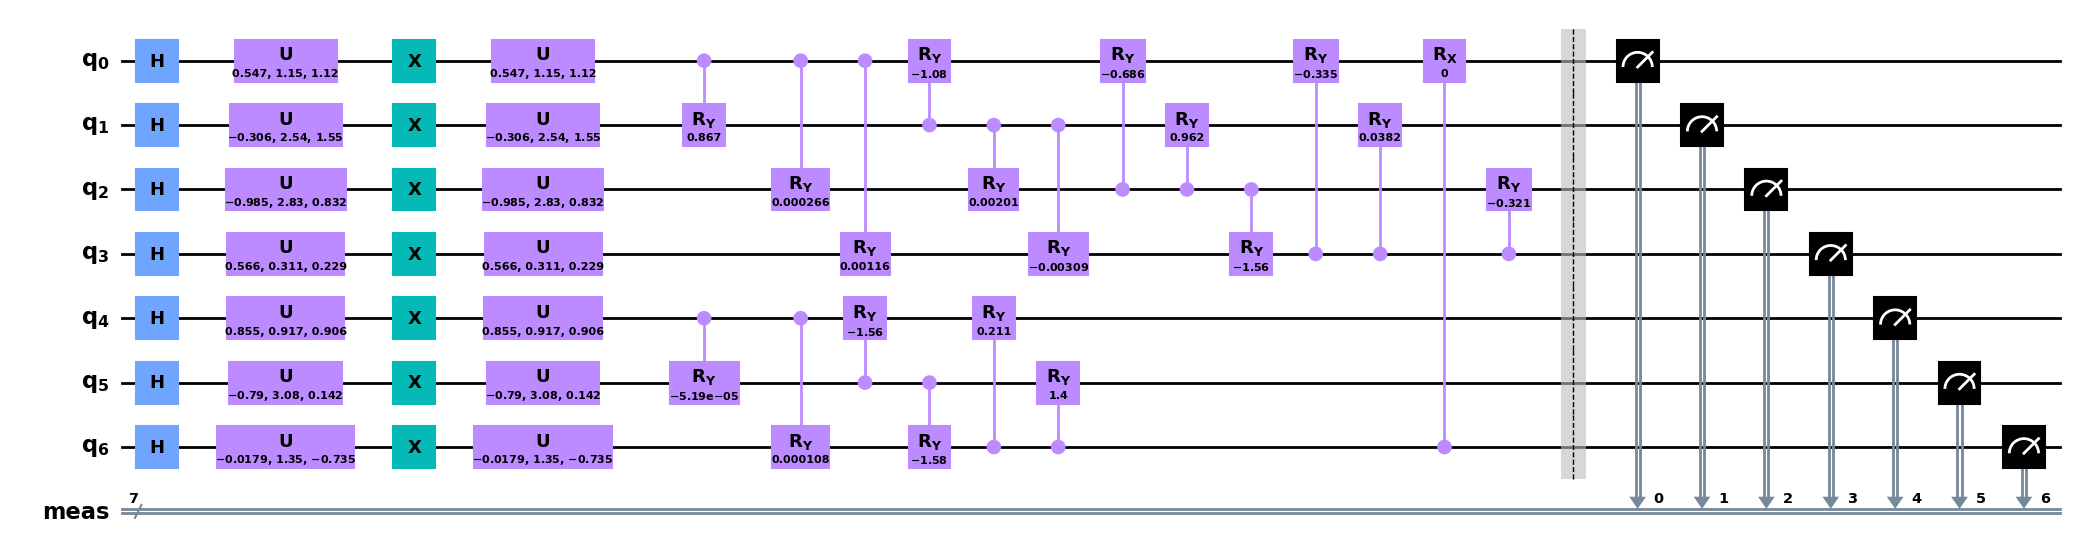

In [28]:
# --- Calling the vqe_lr_solver function with your variables ---
print("--- Starting VQE LR Solver ---")
result_lr_bfgs, optimized_full_params_lr_mo0, cost_values_from_solver = vqe_lr_solver(
    cc_grn_circuit_mo0,
    optimized_full_params_ct1_mo,
    optimized_full_params_ct2_mo,
    interactions_lr,
    ansatz_grn_ct1_mo.num_qubits,
    ansatz_grn_ct2_mo.num_qubits,
    cost_func_wrapper,
    create_parameter_dictionaries_from_circuit,
    create_interaction_observable_general
)

print("\n--- VQE LR Solver Completed ---")
print("Final optimized parameters:", optimized_full_params_lr_mo0)

# --- Plotting the cost values ---
plt.figure(figsize=(10, 6))
plt.plot(cost_values_from_solver)
plt.xlabel("Optimization Iteration")
plt.ylabel("Cost Function Value (Energy)")
plt.title("Energy Minimization Curve (LR Parameters)")
plt.grid(True)
plt.tight_layout()
plt.show()
counts_cc_grn_mo0, bound_circuit = evaluate_and_plot_ansatz(cc_grn_circuit_mo0, optimized_full_params_lr_mo0, shots=1024, title="Circuit Results")
bound_circuit.draw(output="mpl", style="clifford", fold=40)  # Show the circuit plot

In [29]:
def filter_bitstrings_from_interactions(interactions_lr, num_qubits):
    """
    Generates bit string patterns based on the given interactions_lr
    for plotting specific bitstring patterns.
    Args:
        interactions_lr (dict): A dictionary representing interactions,
                                 where keys are tuples of qubit indices
                                 and values are interaction strengths.
        num_qubits (int): The total number of qubits in the system.

    Returns:
        list: A list of bit string patterns with '1' at the interacting
              qubit positions and '0' elsewhere.
    """
    patterns = []
    for interaction in interactions_lr:
        pattern = ['.'] * num_qubits
        for qubit_index in interaction:
            if 0 <= qubit_index < num_qubits:
                pattern[num_qubits - 1 - qubit_index] = '1'  # Adjust for bit order
        patterns.append("".join(pattern))
    return patterns

bitstring_patterns = filter_bitstrings_from_interactions(interactions_lr, cc_grn_circuit_co.num_qubits)
print(bitstring_patterns)

['1.....1']


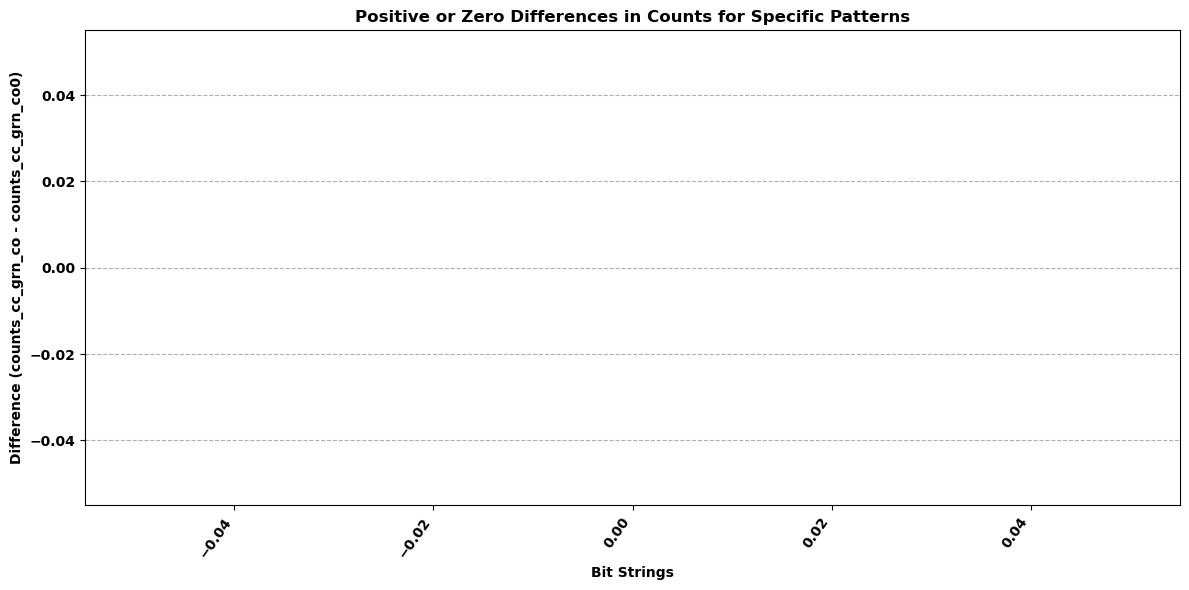

In [30]:
import matplotlib.pyplot as plt
import numpy as np

# Assume counts_cc_grn_co0 and counts_cc_grn_co are defined dictionaries here.
# Assume bitstring_patterns is a defined list of patterns here.

differences_co = {}

# Calculate the differences, handling cases where bitstrings are not common
all_bitstrings = set(counts_cc_grn_co0.keys()) | set(counts_cc_grn_co.keys())

for key in all_bitstrings:
    count_co0 = counts_cc_grn_co0.get(key, 0)
    count_co = counts_cc_grn_co.get(key, 0)
    differences_co[key] = count_co - count_co0

# Define the pattern matching function
def matches_pattern(bitstring, pattern):
    if len(bitstring) != len(pattern):
        return False
    for i in range(len(bitstring)):
        if pattern[i] != '.' and pattern[i] != bitstring[i]:
            return False
    return True

# Filter bitstrings based on the defined patterns first
pattern_filtered_bitstrings = []
pattern_filtered_differences = []

for bitstring, difference in differences_co.items():
    for pattern in bitstring_patterns:
        if matches_pattern(bitstring, pattern):
            # Keep this bitstring and difference if it matches any pattern
            pattern_filtered_bitstrings.append(bitstring)
            pattern_filtered_differences.append(difference)
            break # Move to the next bitstring once a match is found

# --- Filter for positive or zero differences ONLY ---
# Create new lists containing only the elements where the difference is >= 0
filtered_bitstrings_co = [] # Rename to clarify these are the final filtered lists
filtered_differences_co = []

# Iterate through the pattern-filtered data and keep only positive/zero differences
for bitstring, difference in zip(pattern_filtered_bitstrings, pattern_filtered_differences):
    if difference > 0: # Keep only positive or zero differences
        filtered_bitstrings_co.append(bitstring)
        filtered_differences_co.append(difference)

# --- End of filtering for positive differences ---


# Sort the filtered bitstrings for better visualization
# This sorting now applies only to the bitstrings with positive differences
sorted_indices = np.argsort(filtered_bitstrings_co)
filtered_bitstrings_co = [filtered_bitstrings_co[i] for i in sorted_indices]
filtered_differences_co = [filtered_differences_co[i] for i in sorted_indices] # Apply same sorting to differences


# Create the bar plot with the positively filtered data
plt.figure(figsize=(12, 6))
bars = plt.bar(filtered_bitstrings_co, filtered_differences_co, edgecolor='black')

# Color the bars - since we only have >=0 differences, all will be blue
for bar, diff in zip(bars, filtered_differences_co):
    if diff > 0:
        bar.set_color('blue')  # Color for positive differences
    else: # This case is for diff == 0, also color blue if desired
         bar.set_color('blue') # Or another color if you want 0s distinct


plt.xlabel('Bit Strings')
# Assuming the ylabel describes the original difference calculation
plt.ylabel('Difference (counts_cc_grn_co - counts_cc_grn_co0)')
plt.title('Positive or Zero Differences in Counts for Specific Patterns') # Updated title
plt.xticks(rotation=55, ha='right')
plt.tight_layout()
plt.grid(axis='y', linestyle='--')
plt.show()

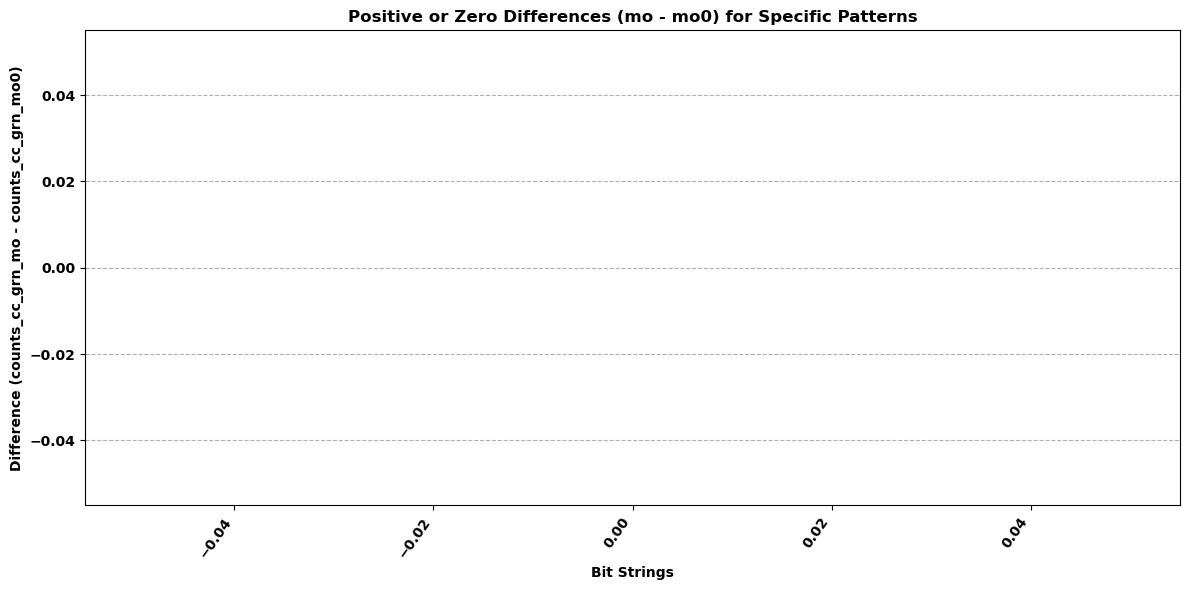

In [31]:
import matplotlib.pyplot as plt
import numpy as np

# Assume counts_cc_grn_mo0 and counts_cc_grn_mo are defined dictionaries here.
# Assume bitstring_patterns is a defined list of patterns here.

differences_mo = {}

# Calculate the differences, handling cases where bitstrings are not common
all_bitstrings = set(counts_cc_grn_mo0.keys()) | set(counts_cc_grn_mo.keys())

for key in all_bitstrings:
    count_mo0 = counts_cc_grn_mo0.get(key, 0)
    count_mo = counts_cc_grn_mo.get(key, 0)
    differences_mo[key] = count_mo - count_mo0

# Define the pattern matching function (assuming it's the same as before)
def matches_pattern(bitstring, pattern):
    if len(bitstring) != len(pattern):
        return False
    for i in range(len(bitstring)):
        if pattern[i] != '.' and pattern[i] != bitstring[i]:
            return False
    return True

# Filter bitstrings based on the defined patterns first
pattern_filtered_bitstrings = []
pattern_filtered_differences = []

for bitstring, difference in differences_mo.items():
    for pattern in bitstring_patterns:
        if matches_pattern(bitstring, pattern):
            # Keep this bitstring and difference if it matches any pattern
            pattern_filtered_bitstrings.append(bitstring)
            pattern_filtered_differences.append(difference)
            break # Move to the next bitstring once a match is found

# --- Filter for positive or zero differences ONLY ---
# Create new lists containing only the elements where the difference is >= 0
filtered_bitstrings_mo = [] # Use these names for the final lists
filtered_differences_mo = []

# Iterate through the pattern-filtered data and keep only positive/zero differences
for bitstring, difference in zip(pattern_filtered_bitstrings, pattern_filtered_differences):
    if difference > 0: # Keep only positive or zero differences
        filtered_bitstrings_mo.append(bitstring)
        filtered_differences_mo.append(difference)

# --- End of filtering for positive differences ---


# Sort the filtered bitstrings for better visualization
# This sorting now applies only to the bitstrings with positive differences
sorted_indices = np.argsort(filtered_bitstrings_mo)
filtered_bitstrings_mo = [filtered_bitstrings_mo[i] for i in sorted_indices]
filtered_differences_mo = [filtered_differences_mo[i] for i in sorted_indices] # Apply same sorting to differences


# Create the bar plot with the positively filtered data
plt.figure(figsize=(12, 6))
bars = plt.bar(filtered_bitstrings_mo, filtered_differences_mo, edgecolor='black')

# Color the bars - since we only have >=0 differences, all will typically be colored the same
for bar, diff in zip(bars, filtered_differences_mo):
    # Note: with >=0 filtering, only diff > 0 or diff == 0 will be plotted
    if diff > 0:
        bar.set_color('blue')  # Color for strictly positive differences
    else: # This handles diff == 0 cases
         bar.set_color('blue') # You can choose a different color here if you want 0s distinct

plt.xlabel('Bit Strings')
# Update ylabel to reflect the specific difference calculated in this block
plt.ylabel('Difference (counts_cc_grn_mo - counts_cc_grn_mo0)')
# Update title to reflect the specific data and filtering applied
plt.title('Positive or Zero Differences (mo - mo0) for Specific Patterns')
plt.xticks(rotation=55, ha='right')
plt.tight_layout()
plt.grid(axis='y', linestyle='--')
plt.show()

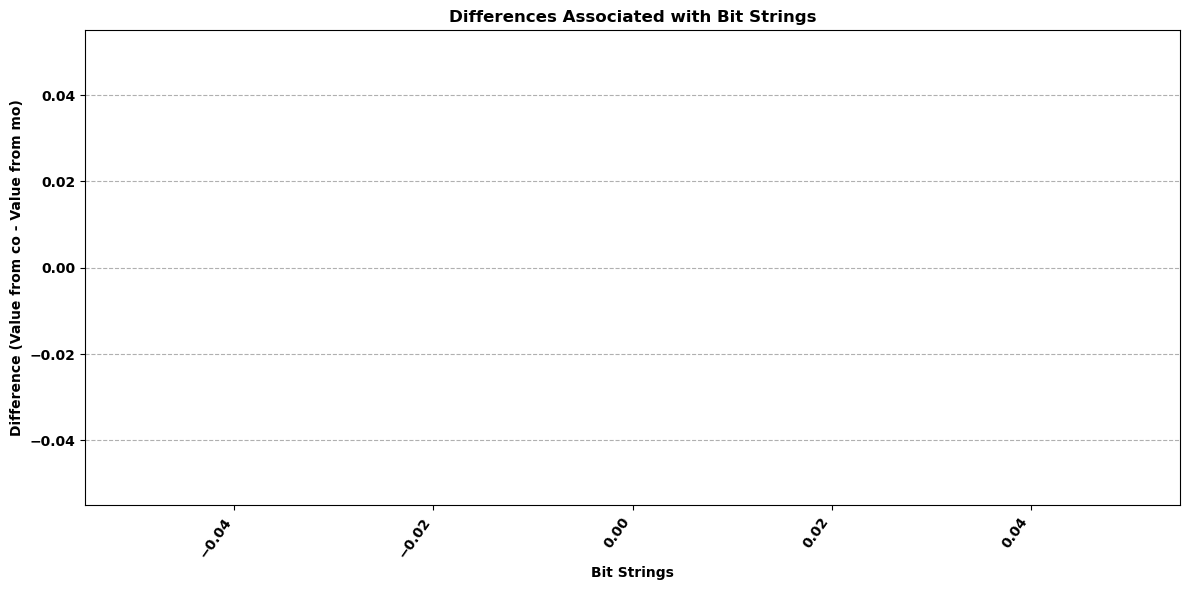

In [32]:
import matplotlib.pyplot as plt
import numpy as np


# We assume filtered_bitstrings_mo[i] corresponds to filtered_differences_mo[i], etc.
mo_data = dict(zip(filtered_bitstrings_mo, filtered_differences_mo))
co_data = dict(zip(filtered_bitstrings_co, filtered_differences_co))

all_bitstrings = set(mo_data.keys()) | set(co_data.keys())

# Initialize a dictionary to store the calculated differences
calculated_differences = {}

for bitstring in all_bitstrings:
    # Get the value for this bitstring from each dictionary
    # Use .get() with a default of 0 in case the bitstring is only in one list
    val_mo = mo_data.get(bitstring, 0)
    val_co = co_data.get(bitstring, 0)

    # Calculate the difference (co - mo)
    calculated_differences[bitstring] = val_co - val_mo

# 4. Prepare data for plotting (separate lists for bitstrings and differences)
plot_bitstrings = list(calculated_differences.keys())
plot_differences = list(calculated_differences.values())

# 5. Sort the data based on bitstring for better visualization (optional but recommended)
sorted_indices = np.argsort(plot_bitstrings)
plot_bitstrings = [plot_bitstrings[i] for i in sorted_indices]
plot_differences = [plot_differences[i] for i in sorted_indices]

# 6. Create the bar plot using the calculated differences
plt.figure(figsize=(12, 6))
bars = plt.bar(plot_bitstrings, plot_differences, edgecolor='black')

# 7. Color the bars based on the sign of the difference
for bar, diff in zip(bars, plot_differences):
    if diff > 0:
        bar.set_color('blue')  # Color for positive differences
    else:
        bar.set_color('red')   # Color for negative differences

plt.xlabel('Bit Strings')
plt.ylabel('Difference (Value from co - Value from mo)') # Updated label
plt.title('Differences Associated with Bit Strings')     # Updated title
plt.xticks(rotation=55, ha='right')
plt.tight_layout() # Adjust layout to prevent labels overlapping
plt.grid(axis='y', linestyle='--')
plt.show()

In [33]:
print(gl_recv[::-1], gl_source[::-1])

['TGFB1', 'FN1', 'PDGFRB'] ['PDGFB', 'HIF1A', 'SMAD3', 'TGFBR2']


--- Concatenated DataFrame (bound_qc_co vs bound_qc_mo) ---
       Prob_0_co  Prob_1_co     Prob_0_mo     Prob_1_mo
Qubit                                                  
0       0.998104   0.001896  9.999543e-01  4.568867e-05
1       0.006366   0.993634  1.939488e-04  9.998061e-01
2       0.008338   0.991662  3.324633e-04  9.996675e-01
3       0.995702   0.004298  9.997800e-01  2.200109e-04
4       0.993816   0.006184  9.999959e-01  4.058642e-06
5       0.000005   0.999995  1.008195e-08  1.000000e+00
6       0.999927   0.000073  1.000000e+00  2.278774e-08
------------------------------------------------------------
--- Concatenated DataFrame (bound_qc_co0 vs bound_qc_mo0) ---
       Prob_0_co0  Prob_1_co0    Prob_0_mo0    Prob_1_mo0
Qubit                                                    
0        0.998176    0.001824  9.999543e-01  4.568867e-05
1        0.006366    0.993634  1.939488e-04  9.998061e-01
2        0.008338    0.991662  3.324633e-04  9.996675e-01
3        0.995702    0.

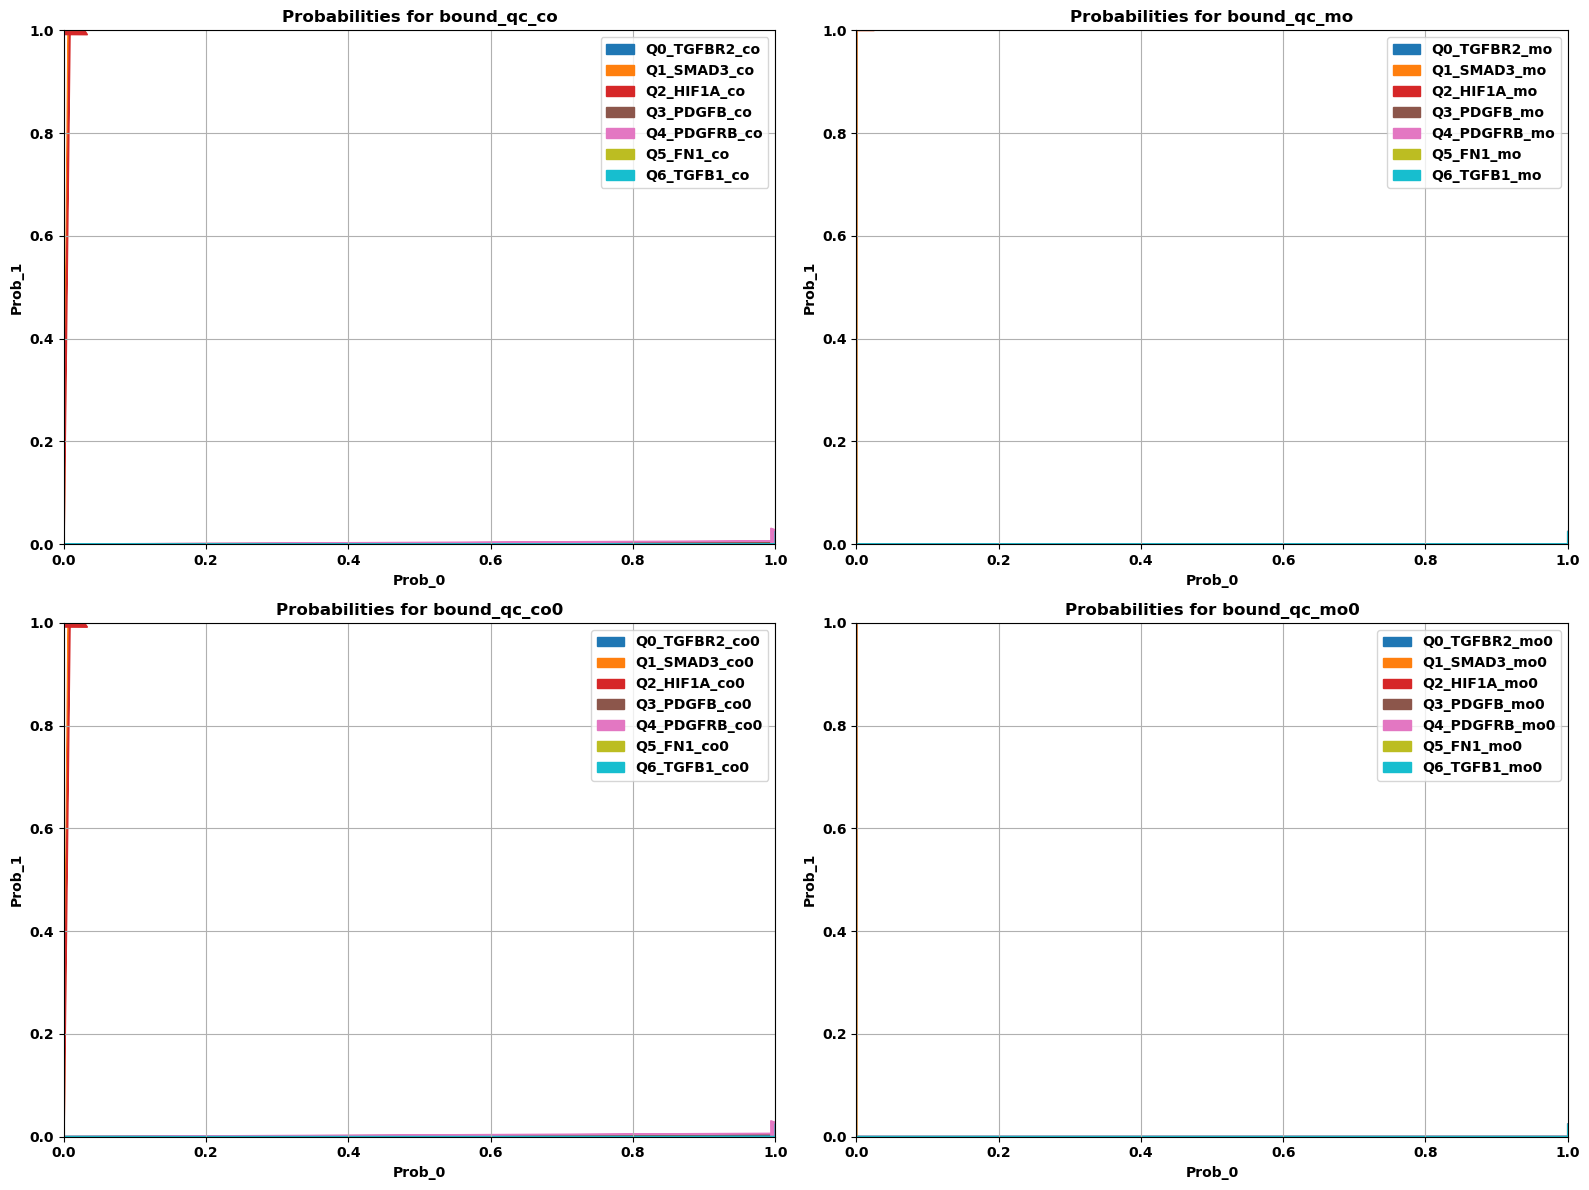

In [34]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd # Import pandas for DataFrames
from qiskit.exceptions import QiskitError
from qiskit.quantum_info import DensityMatrix, Statevector, partial_trace

# Assuming the following variables are defined elsewhere:
# cc_grn_circuit_co, cc_grn_circuit_mo, cc_grn_circuit_co0, cc_grn_circuit_mo0
# all_params_lr_co, all_params_lr_mo, all_params_lr_co0, all_params_lr_mo0
# gl_source, gl_recv

# --- Data Calculation for bound_qc_co and bound_qc_mo ---
bound_qc_co_circ = cc_grn_circuit_co.copy()
bound_qc_co_circ.assign_parameters(optimized_full_params_lr_co, inplace=True)

bound_qc_mo_circ = cc_grn_circuit_mo.copy()
bound_qc_mo_circ.assign_parameters(optimized_full_params_lr_mo, inplace=True)

# Assume number of qubits is the same across all circuits
n_qubits = DensityMatrix(bound_qc_co_circ).num_qubits


co_data_bound = []
density_matrix_co_bound = DensityMatrix(bound_qc_co_circ)
for qubit_to_keep in range(n_qubits):
    trace_out_qubits = list(range(n_qubits))
    trace_out_qubits.pop(qubit_to_keep)
    reduced_density_matrix_data = partial_trace(density_matrix_co_bound, trace_out_qubits).data
    prob_0 = np.real(reduced_density_matrix_data[0, 0])
    prob_1 = np.real(reduced_density_matrix_data[1, 1])
    co_data_bound.append([qubit_to_keep, prob_0, prob_1])

mo_data_bound = []
density_matrix_mo_bound = DensityMatrix(bound_qc_mo_circ)
for qubit_to_keep in range(n_qubits):
    trace_out_qubits = list(range(n_qubits))
    trace_out_qubits.pop(qubit_to_keep)
    reduced_density_matrix_data = partial_trace(density_matrix_mo_bound, trace_out_qubits).data
    prob_0 = np.real(reduced_density_matrix_data[0, 0])
    prob_1 = np.real(reduced_density_matrix_data[1, 1])
    mo_data_bound.append([qubit_to_keep, prob_0, prob_1])

# Create DataFrames for bound data (add suffixes to column names)
co_df_bound = pd.DataFrame(co_data_bound, columns=['Qubit', 'Prob_0_co', 'Prob_1_co'])
mo_df_bound = pd.DataFrame(mo_data_bound, columns=['Qubit', 'Prob_0_mo', 'Prob_1_mo'])

# Concatenate DataFrames for bound data and print
concatenated_df_bound = pd.concat([co_df_bound.set_index('Qubit'), mo_df_bound.set_index('Qubit')], axis=1)
print("--- Concatenated DataFrame (bound_qc_co vs bound_qc_mo) ---")
print(concatenated_df_bound)
print("-" * 60) # Separator


# --- Data Calculation for bound_qc_co0 and bound_qc_mo0 ---
bound_qc_co0_circ = cc_grn_circuit_co0.copy()
bound_qc_co0_circ.assign_parameters(optimized_full_params_lr_co0, inplace=True)

bound_qc_mo0_circ = cc_grn_circuit_mo0.copy()
bound_qc_mo0_circ.assign_parameters(optimized_full_params_lr_mo0, inplace=True)

co_data_bound0 = []
density_matrix_co_bound0 = DensityMatrix(bound_qc_co0_circ)
for qubit_to_keep in range(n_qubits):
    trace_out_qubits = list(range(n_qubits))
    trace_out_qubits.pop(qubit_to_keep)
    reduced_density_matrix_data = partial_trace(density_matrix_co_bound0, trace_out_qubits).data
    prob_0 = np.real(reduced_density_matrix_data[0, 0])
    prob_1 = np.real(reduced_density_matrix_data[1, 1])
    co_data_bound0.append([qubit_to_keep, prob_0, prob_1])

mo_data_bound0 = []
density_matrix_mo_bound0 = DensityMatrix(bound_qc_mo0_circ)
for qubit_to_keep in range(n_qubits):
    trace_out_qubits = list(range(n_qubits))
    trace_out_qubits.pop(qubit_to_keep)
    reduced_density_matrix_data = partial_trace(density_matrix_mo_bound0, trace_out_qubits).data
    prob_0 = np.real(reduced_density_matrix_data[0, 0])
    prob_1 = np.real(reduced_density_matrix_data[1, 1])
    mo_data_bound0.append([qubit_to_keep, prob_0, prob_1])

# Create DataFrames for bound0 data (add suffixes to column names)
co_df_bound0 = pd.DataFrame(co_data_bound0, columns=['Qubit', 'Prob_0_co0', 'Prob_1_co0'])
mo_df_bound0 = pd.DataFrame(mo_data_bound0, columns=['Qubit', 'Prob_0_mo0', 'Prob_1_mo0'])

# Concatenate DataFrames for bound0 data and print
concatenated_df_bound0 = pd.concat([co_df_bound0.set_index('Qubit'), mo_df_bound0.set_index('Qubit')], axis=1)
print("--- Concatenated DataFrame (bound_qc_co0 vs bound_qc_mo0) ---")
print(concatenated_df_bound0)
print("-" * 60) # Separator


# --- Plotting in a single 2x2 panel ---

# Create a figure with 2 rows and 2 columns of subplots
fig, axes = plt.subplots(2, 2, figsize=(16, 12)) # Adjust figsize as needed

# Define colors for each qubit using tab20 or tab10 (consistent coloring across plots)
if n_qubits <= 10:
    colors = plt.cm.tab10(np.linspace(0, 1, n_qubits))
else:
    colors = plt.cm.tab20(np.linspace(0, 1, n_qubits))

# Concatenate genes (assuming gl_source and gl_recv are lists of gene names corresponding to qubits)
genes = gl_source + gl_recv

# --- Plotting on each subplot ---

# Plot for bound_qc_co (Top-Left Subplot)
ax1 = axes[0, 0]
for index, row in co_df_bound.iterrows(): # Use co_df_bound here
    ax1.arrow(0, 0, row['Prob_0_co'], row['Prob_1_co'], # Use correct column names
              head_width=0.05, head_length=0.05, fc=colors[index], ec=colors[index],
              label=f"Q{int(row['Qubit'])}_{genes[index]}_co")

ax1.set_xlabel('Prob_0')
ax1.set_ylabel('Prob_1')
ax1.set_title('Probabilities for bound_qc_co')
ax1.grid(True)
ax1.set_xlim(0, 1)
ax1.set_ylim(0, 1)
ax1.legend()


# Plot for bound_qc_mo (Top-Right Subplot)
ax2 = axes[0, 1]
for index, row in mo_df_bound.iterrows(): # Use mo_df_bound here
    ax2.arrow(0, 0, row['Prob_0_mo'], row['Prob_1_mo'], # Use correct column names
              head_width=0.05, head_length=0.05, fc=colors[index], ec=colors[index],
              label=f"Q{int(row['Qubit'])}_{genes[index]}_mo")

ax2.set_xlabel('Prob_0')
ax2.set_ylabel('Prob_1')
ax2.set_title('Probabilities for bound_qc_mo')
ax2.grid(True)
ax2.set_xlim(0, 1)
ax2.set_ylim(0, 1)
ax2.legend()


# Plot for bound_qc_co0 (Bottom-Left Subplot)
ax3 = axes[1, 0]
for index, row in co_df_bound0.iterrows(): # Use co_df_bound0 here
    ax3.arrow(0, 0, row['Prob_0_co0'], row['Prob_1_co0'], # Use correct column names
              head_width=0.05, head_length=0.05, fc=colors[index], ec=colors[index],
              label=f"Q{int(row['Qubit'])}_{genes[index]}_co0")

ax3.set_xlabel('Prob_0')
ax3.set_ylabel('Prob_1')
ax3.set_title('Probabilities for bound_qc_co0')
ax3.grid(True)
ax3.set_xlim(0, 1)
ax3.set_ylim(0, 1)
ax3.legend()


# Plot for bound_qc_mo0 (Bottom-Right Subplot)
ax4 = axes[1, 1]
for index, row in mo_df_bound0.iterrows(): # Use mo_df_bound0 here
    ax4.arrow(0, 0, row['Prob_0_mo0'], row['Prob_1_mo0'], # Use correct column names
              head_width=0.05, head_length=0.05, fc=colors[index], ec=colors[index],
              label=f"Q{int(row['Qubit'])}_{genes[index]}_mo0")

ax4.set_xlabel('Prob_0')
ax4.set_ylabel('Prob_1')
ax4.set_title('Probabilities for bound_qc_mo0')
ax4.grid(True)
ax4.set_xlim(0, 1)
ax4.set_ylim(0, 1)
ax4.legend()


# Adjust layout and display the plot
plt.tight_layout()
plt.show()